> Goal: building a **demo notebook** to *see inside* the disparity filter and related visuals

In [ ]:
# Cell A — Imports, Settings, Debug Levels

import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
import random

# Plot style (non-intrusive)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Debug levels
DEBUG_NONE = 0
DEBUG_LIGHT = 1   # concise star summaries
DEBUG_VERBOSE = 2 # full per-node, per-edge lines

def rng(seed=7):
    """Numpy Generator for reproducibility."""
    return np.random.default_rng(int(seed))

- **LIGHT**: shows top neighbors per inspected star and per-module summaries.
- **VERBOSE**: prints *every* local alpha test per edge (great for small graphs, noisy for big ones).

## Graph Generators (undirected + directed)

the disparity filter behaves **very differently** depending on topology. You need many structures to develop intuition.

* **ER** = random wiring. Low clustering.
* **WS** = small-world (ring + rewiring). High clustering + short paths.
* **BA** = preferential attachment. Scale-free degrees, hub-heavy.
* **SBM** = communities (intra >> inter).
* **Geometric** = edges by spatial proximity.
* **Tree/Path/Star** = acyclic/simple baselines.
* **Complete** = densest baseline.
* **DirER** = directed random wiring.


In [24]:
# Cell B — Graph Generators (undirected + directed)

def make_er(n=300, p=0.02, seed=7):
    return nx.fast_gnp_random_graph(n, p, seed=seed)

def make_ws(n=300, k=6, p=0.05, seed=7):
    return nx.watts_strogatz_graph(n, k, p, seed=seed)

def make_ba(n=300, m=3, seed=7):
    return nx.barabasi_albert_graph(n, m, seed=seed)

def make_sbm(sizes=(120, 120, 120), p_in=0.05, p_out=0.005, seed=7):
    R = rng(seed)
    B = len(sizes)
    P = np.full((B, B), p_out, dtype=float)
    np.fill_diagonal(P, p_in)
    return nx.stochastic_block_model(sizes, P, seed=int(R.integers(10_000)))

def make_geometric(n=300, r=0.12, seed=7):
    R = rng(seed)
    pos = {i: (float(R.random()), float(R.random())) for i in range(n)}
    G = nx.random_geometric_graph(n, r, pos=pos)
    nx.set_node_attributes(G, pos, "pos")
    return G

def make_random_tree(n=300, seed=7):
    return nx.random_tree(n, seed=seed)

def make_star(n=300):
    return nx.star_graph(n-1)

def make_path(n=300):
    return nx.path_graph(n)

def make_complete(n=120):
    return nx.complete_graph(n)

def make_bipartite(n1=150, n2=150, p=0.05, seed=7):
    R = rng(seed)
    U = range(n1)
    V = range(n1, n1+n2)
    G = nx.Graph()
    G.add_nodes_from(U, bipartite=0)
    G.add_nodes_from(V, bipartite=1)
    for u in U:
        for v in V:
            if R.random() < p:
                G.add_edge(u, v)
    return G

def make_dir_er(n=300, p=0.02, seed=7):
    return nx.gnp_random_graph(n, p, seed=seed, directed=True)

def make_suite(seed=7):
    return {
        "ER": make_er(seed=seed),
        "WS": make_ws(seed=seed),
        "BA": make_ba(seed=seed),
        "SBM": make_sbm(seed=seed),
        "Geometric": make_geometric(seed=seed),
        "Tree": make_random_tree(seed=seed),
        "Star": make_star(),
        "Path": make_path(),
        "Complete": make_complete(),
        "Bipartite": make_bipartite(seed=seed),
        "DirER": make_dir_er(seed=seed),
    }


## Weighting Schemes (positive weights only)

disparity tests are **local and relative**. If weights are flat, you’ll keep almost nothing unless $\alpha$ is very loose. With heavy tails, you keep **few edges but lots of weight**.

* All weights must be **strictly positive**. The filter will error out otherwise (good!).

* **lognormal**: heavy-tailed weights, independent from degrees.
* **pareto**: even heavier tail (bursty ties).
* **uniform**: nearly flat weights (diagnostic case).
* **gravity**: $w_{ij} \propto \frac{m_i m_j}{d(i,j)^\beta}$ (uses `pos` or force-layout distances). Great on Geometric.
* **degprod**: $w_{ij} \propto (\deg i,\deg j)^\gamma$ (+ small noise). Correlates weight with structure.

In [25]:
# Cell C — Weighting Schemes (positive weights only)

def assign_weights(G, scheme="lognormal", weight="weight", seed=7, **kwargs):
    """
    Add positive weights to edges of G.
      - 'lognormal': w = exp(N(mu,sigma)), kwargs: mu=0, sigma=1
      - 'pareto'   : w = 1 + Pareto(alpha), kwargs: alpha=1.5
      - 'uniform'  : w ~ U[a,b], kwargs: a=0.5, b=1.5
      - 'gravity'  : w ~ (m_u m_v) / d(u,v)^beta, kwargs: beta=1.0 (uses 'pos' or springs)
      - 'degprod'  : w ~ (deg(u)*deg(v))^gamma + noise, kwargs: gamma=0.5, eps=1e-3
    """
    R = rng(seed)
    mu = kwargs.get("mu", 0.0)
    sigma = kwargs.get("sigma", 1.0)
    alpha = kwargs.get("alpha", 1.5)
    a = kwargs.get("a", 0.5)
    b = kwargs.get("b", 1.5)
    beta = kwargs.get("beta", 1.0)
    gamma = kwargs.get("gamma", 0.5)
    eps = kwargs.get("eps", 1e-3)

    deg = dict(G.degree())
    pos = nx.get_node_attributes(G, "pos") or None

    for u, v in G.edges():
        if scheme == "lognormal":
            w = float(np.exp(R.normal(mu, sigma)))
        elif scheme == "pareto":
            w = float(1.0 + R.pareto(alpha))
        elif scheme == "uniform":
            w = float(R.uniform(a, b))
        elif scheme == "gravity":
            if pos is None:
                pos = nx.spring_layout(G, seed=42)  # cache after first compute
            pu, pv = np.array(pos[u]), np.array(pos[v])
            d = float(np.linalg.norm(pu - pv)) + 1e-9
            mu_u = 1.0 + deg[u]
            mu_v = 1.0 + deg[v]
            w = (mu_u * mu_v) / (d ** beta)
        elif scheme == "degprod":
            w = ((deg[u] * deg[v]) ** gamma) + float(R.lognormal(0, 0.1)) + eps
        else:
            raise ValueError(f"Unknown scheme: {scheme}")
        G[u][v][weight] = float(max(w, eps))
    return G


## Disparity Filter 

*Serrano–Boguñá–Vespignani (PNAS 2009) **disparity filter**.

* The star prints are the **microscope**: only the top few $p_{ij}$ typically pass.
* On hubs (large $k$), the test is stricter—$p^*$ is higher.

**Minimal math**:

* Normalize at node $i$: $p_{ij} = \omega_{ij}/s_i$, with $s_i = \sum_j \omega_{ij}$.
* Null (uniform split among $k_i$ edges): $p \sim \mathrm{Beta}(1,k_i-1)$.
* Right-tail p-value: $\alpha_{ij} = (1-p_{ij})^{k_i-1}$.
* Keep $(i,j)$ if **OR-rule**: $\alpha_{ij}<\alpha$ **or** $\alpha_{ji}<\alpha$ (protects small nodes).
  (You can switch to **AND-rule** to be stricter.)

**What we'll see on `DEBUG_LIGHT`**:

* A header line with graph size and parameters.
* **“Star samples”**: for a few high-degree nodes, a table of neighbors sorted by $p_{ij}$ with `keep? True/False`.
* The **local threshold** $p^*(\alpha,k) = 1 - \alpha^{1/(k-1)}$ reported per star.

**Why it matters**:

* The star prints are the **microscope**: only the top few $p_{ij}$ typically pass.
* On hubs (large $k$), the test is stricter—$p^*$ is higher.

**Sanity checks**:

* If you get *zero* edges for many settings, you may have:
  (i) overly flat weights, (ii) too small $\alpha$, (iii) the **degprod** case where structure explains weights (the filter becomes very picky).


In [61]:
# Cell D — Disparity Filter (with strict validation + debug)

def _ensure_positive_weights(G, weight):
    for u, v, d in G.edges(data=True):
        if weight not in d or not (d[weight] > 0):
            raise ValueError(f"Edge ({u},{v}) missing positive '{weight}'.")

def local_threshold_pstar(alpha, k):
    """p* such that (1 - p*)^(k-1) = alpha ⇒ p* = 1 - alpha^(1/(k-1))"""
    if k <= 1:
        return 1.0
    return 1.0 - (alpha ** (1.0 / (k - 1)))

def disparity_filter(
    G,
    alpha=0.05,
    rule="or",  # 'or' (paper) or 'and'
    directed=None,
    weight="weight",
    keep_isolates=True,
    debug=DEBUG_LIGHT,
    max_debug_nodes=5
):
    """
    Serrano–Boguñá–Vespignani (PNAS 2009) disparity filter.
    p_ij = w_ij / s_i, with null p ~ Beta(1, k_i-1).
    Keep edge if significant at SOURCE or TARGET ('or'), or both ('and').
    """
    if directed is None:
        directed = G.is_directed()
    _ensure_positive_weights(G, weight)

    if not directed:
        # undirected case
        s = {i: 0.0 for i in G.nodes()}
        k = {i: 0   for i in G.nodes()}
        for i in G:
            nbrs = G[i]
            k[i] = len(nbrs)
            if k[i] > 0:
                s[i] = sum(G[i][j][weight] for j in nbrs)

        def alpha_at(i, j):
            ki = k[i]
            if ki <= 1:
                return 0.0
            pij = G[i][j][weight] / s[i]
            return (1.0 - pij) ** (ki - 1)

        if debug >= DEBUG_LIGHT:
            print(f"[Undirected] alpha={alpha}, rule={rule}, nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
            print("[Star samples]")
            shown = 0
            for i in sorted(G, key=lambda v: G.degree(v), reverse=True):
                if shown >= max_debug_nodes:
                    break
                if k[i] == 0:
                    continue
                rows = []
                for j in G[i]:
                    pij = G[i][j][weight] / (s[i] if s[i] > 0 else 1.0)
                    aij = alpha_at(i, j)
                    rows.append((j, pij, aij, aij < alpha))
                rows.sort(key=lambda x: x[1], reverse=True)
                print(f"  node {i}: k={k[i]:>3}, s={s[i]:.4f}, p*={local_threshold_pstar(alpha,k[i]):.6f}")
                for j, pij, aij, keep in rows[:min(8,len(rows))]:
                    print(f"    (i,j)=({i},{j}) p={pij:.4f}  a={aij:.6f}  keep? {keep}")
                shown += 1

        kept = []
        for u, v in G.edges():
            au = alpha_at(u, v)
            av = alpha_at(v, u)
            ok = (au < alpha) or (av < alpha) if rule == "or" else (au < alpha) and (av < alpha)
            if ok:
                d = dict(G[u][v])
                d["alpha_u"] = au
                d["alpha_v"] = av
                kept.append((u, v, d))
            if debug == DEBUG_VERBOSE:
                print(f"[TEST] ({u},{v}): a_u={au:.6g}  a_v={av:.6g}  -> keep={ok}")

        B = nx.Graph()
        if keep_isolates:
            B.add_nodes_from(G.nodes(data=True))
        B.add_edges_from(kept)
        return B

    else:
        # directed case
        kout = {i: G.out_degree(i) for i in G}
        kin  = {i: G.in_degree(i)  for i in G}
        sout = {i: 0.0 for i in G}
        sin  = {i: 0.0 for i in G}
        for u, v, d in G.edges(data=True):
            w = d[weight]
            sout[u] += w
            sin[v]  += w

        def alpha_out(u, v):
            ku = kout[u]
            if ku <= 1:
                return 0.0
            p = G[u][v][weight] / (sout[u] if sout[u] > 0 else 1.0)
            return (1.0 - p) ** (ku - 1)

        def alpha_in(u, v):
            kv = kin[v]
            if kv <= 1:
                return 0.0
            p = G[u][v][weight] / (sin[v] if sin[v] > 0 else 1.0)
            return (1.0 - p) ** (kv - 1)

        if debug >= DEBUG_LIGHT:
            print(f"[Directed] alpha={alpha}, rule={rule}, nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
            print("[Star samples: OUT then IN]")
            shown = 0
            for i in list(G.nodes())[:max_debug_nodes]:
                if kout[i] > 0:
                    items = []
                    for v in G.successors(i):
                        p = G[i][v][weight] / (sout[i] if sout[i] > 0 else 1.0)
                        a = alpha_out(i, v)
                        items.append((v, p, a, a < alpha))
                    items.sort(key=lambda x: x[1], reverse=True)
                    print(f"  src {i}: kout={kout[i]:>3}, sout={sout[i]:.4f}")
                    for v, p, a, keep in items[:min(8,len(items))]:
                        print(f"    -> ({v}) p={p:.4f}  a={a:.6f} keep? {keep}")
                if kin[i] > 0:
                    items = []
                    for u in G.predecessors(i):
                        p = G[u][i][weight] / (sin[i] if sin[i] > 0 else 1.0)
                        a = alpha_in(u, i)
                        items.append((u, p, a, a < alpha))
                    items.sort(key=lambda x: x[1], reverse=True)
                    print(f"  tgt {i}: kin={kin[i]:>3}, sin={sin[i]:.4f}")
                    for u, p, a, keep in items[:min(8,len(items))]:
                        print(f"    <- ({u}) p={p:.4f}  a={a:.6f} keep? {keep}")
                shown += 1
                if shown >= max_debug_nodes:
                    break

        kept = []
        for u, v in G.edges():
            a_out = alpha_out(u, v)
            a_in  = alpha_in(u, v)
            ok = (a_out < alpha) or (a_in < alpha) if rule == "or" else (a_out < alpha) and (a_in < alpha)
            if ok:
                d = dict(G[u][v])
                d["alpha_out_u"] = a_out
                d["alpha_in_v"]  = a_in
                kept.append((u, v, d))
            if debug == DEBUG_VERBOSE:
                print(f"[TEST] {u}->{v}: a_out={a_out:.6g} a_in={a_in:.6g} -> keep={ok}")

        B = nx.DiGraph()
        if keep_isolates:
            B.add_nodes_from(G.nodes(data=True))
        B.add_edges_from(kept)
        return B


## Diagnostics & Metrics

* **Weight fraction kept**: $\sum_B w / \sum_G w$.
* **Clustering** wrapper that doesn’t crash on directed graphs.
* **Disparity index** $\Upsilon_i = k_i \sum_j p_{ij}^2$ (how concentrated node $i$’s weights are).
  *Rule of thumb*: $\Upsilon_i \approx 1$ (flat), $\Upsilon_i \gg 1$ (few dominant ties).
* **`alpha_sweep`**: loops over $\alpha$ and logs backbone size, weight kept, clustering, and GCC size.

In [28]:
# Cell E — Diagnostics & Metrics

def fraction_weight_kept(G, B, weight="weight"):
    wG = sum(d.get(weight, 1.0) for *_, d in G.edges(data=True))
    wB = sum(d.get(weight, 1.0) for *_, d in B.edges(data=True))
    return (wB / wG) if wG > 0 else 0.0

def clustering_safe(G):
    try:
        return nx.average_clustering(G)
    except Exception:
        return float("nan")

def disparity_index(G, weight="weight"):
    """Y_i = k_i * sum_j (w_ij/s_i)^2 — larger => weight focuses on few neighbors."""
    if G.is_directed():
        raise ValueError("Use an undirected graph for this Y_i variant.")
    Uy = {}
    for i in G:
        deg = G.degree(i)
        if deg == 0:
            Uy[i] = 0.0
            continue
        s_i = sum(G[i][j][weight] for j in G[i])
        psq = sum((G[i][j][weight]/s_i)**2 for j in G[i]) if s_i>0 else 0.0
        Uy[i] = deg * psq
    return Uy

def alpha_sweep(G, alphas, rule="or", weight="weight", directed=None):
    if directed is None:
        directed = G.is_directed()
    rows = []
    for a in alphas:
        B = disparity_filter(G, alpha=float(a), rule=rule, weight=weight, directed=directed, debug=DEBUG_NONE)
        comps = (list(nx.connected_components(B)) if not directed
                 else list(nx.weakly_connected_components(B)))
        gcc_n = len(max(comps, key=len)) if comps else 0
        rows.append({
            "alpha": float(a),
            "edges_kept": B.number_of_edges(),
            "frac_edges_kept": (B.number_of_edges() / max(1, G.number_of_edges())),
            "frac_weight_kept": fraction_weight_kept(G, B, weight=weight),
            "avg_clustering": (clustering_safe(B) if not directed else float("nan")),
            "gcc_size": gcc_n,
        })
    return rows


## Plot Helpers

* Weight histogram (spot tails quickly).
* Weight vs. degree-product scatter (linear or log–log).
  *Reading tip*: If weight tracks degree-product (degprod scheme), don’t be surprised if the filter is unforgiving.
* Backbone plot with edge widths $\propto \log(1+w)$.
* Disparity index histogram.
* **Alpha curves**: three small figures (edges kept, weight kept, clustering) vs $\alpha$.


In [29]:
# Cell F — Plot Helpers (weight hist, degree-weight, backbone, disparity index)

def _safe_pos(G, seed=3):
    pos_attr = nx.get_node_attributes(G, "pos")
    return pos_attr if len(pos_attr) == G.number_of_nodes() else nx.spring_layout(G, seed=seed)

def plot_weight_hist(G, weight="weight", title="Edge weight histogram"):
    w = [d.get(weight,1.0) for *_, d in G.edges(data=True)]
    plt.figure()
    plt.hist(w, bins=30)
    plt.title(title); plt.xlabel("w"); plt.ylabel("count")
    plt.show()

def plot_degree_weight_scatter(G, weight="weight", title="Edge weight vs degree product"):
    deg = dict(G.degree())
    x, y = [], []
    for u, v, d in G.edges(data=True):
        x.append(max(1, deg[u]*deg[v]))
        y.append(max(1e-12, d.get(weight,1.0)))
    plt.figure()
    plt.scatter(x, y, s=6, alpha=0.6)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("deg(u)*deg(v)"); plt.ylabel("weight")
    plt.title(title)
    plt.show()

def plot_backbone(B, weight="weight", title=None, seed=3):
    pos = _safe_pos(B if B.number_of_edges()>0 else nx.Graph(), seed=seed)
    plt.figure()
    widths = [0.6*math.log1p(d.get(weight,1.0)) for *_, d in B.edges(data=True)]
    nx.draw(B, pos, node_size=12, width=widths)
    plt.title(title or "Backbone (disparity filter)")
    plt.show()

def plot_disparity_index(Uy, title="Disparity index $Y_i$ distribution"):
    vals = list(Uy.values())
    plt.figure()
    plt.hist(vals, bins=30)
    plt.title(title); plt.xlabel("$Y_i$"); plt.ylabel("count")
    plt.show()

def plot_alpha_curves(rows, name="Graph"):
    a_vals = [r["alpha"] for r in rows]
    frac_edges = [r["frac_edges_kept"] for r in rows]
    frac_weight = [r["frac_weight_kept"] for r in rows]
    avg_clust = [r["avg_clustering"] for r in rows]

    plt.figure()
    plt.semilogx(a_vals, frac_edges, marker="o")
    plt.xlabel("alpha (log)"); plt.ylabel("fraction edges kept")
    plt.title(f"{name}: edges kept vs alpha")
    plt.grid(True, which="both"); plt.show()

    plt.figure()
    plt.semilogx(a_vals, frac_weight, marker="o")
    plt.xlabel("alpha (log)"); plt.ylabel("fraction weight kept")
    plt.title(f"{name}: weight kept vs alpha")
    plt.grid(True, which="both"); plt.show()

    if not np.isnan(avg_clust).all():
        plt.figure()
        plt.semilogx(a_vals, avg_clust, marker="o")
        plt.xlabel("alpha (log)"); plt.ylabel("avg clustering (backbone)")
        plt.title(f"{name}: clustering vs alpha")
        plt.grid(True, which="both"); plt.show()


## Utilities

In [45]:
# ---------- Missing helper for the local-star test ----------
def local_threshold_pstar(alpha: float, k: int) -> float:
    """
    Solve (1 - p*)^(k-1) = alpha for p*, used as the local significance cutoff.
    For k <= 1, return 1 (no neighbors -> no meaningful threshold).
    """
    if k <= 1:
        return 1.0
    return 1.0 - (alpha ** (1.0 / (k - 1)))

# ---------- Utilities ----------
def _edge_weights(G, weight="weight"):
    return np.array([d.get(weight, 1.0) for *_, d in G.edges(data=True)], dtype=float)

def _degprod_array(G):
    deg = dict(G.degree())
    x = []
    for u, v in G.edges():
        x.append(max(1, deg[u] * deg[v]))
    return np.array(x, dtype=float)

def _safe_log(arr, tiny=1e-12):
    arr = np.asarray(arr, dtype=float)
    return np.log10(np.clip(arr, tiny, None))

def _basic_stats(arr):
    arr = np.asarray(arr, dtype=float)
    return dict(n=arr.size,
                min=float(np.min(arr)) if arr.size else float('nan'),
                q25=float(np.percentile(arr, 25)) if arr.size else float('nan'),
                median=float(np.median(arr)) if arr.size else float('nan'),
                mean=float(np.mean(arr)) if arr.size else float('nan'),
                q75=float(np.percentile(arr, 75)) if arr.size else float('nan'),
                max=float(np.max(arr)) if arr.size else float('nan'),
                std=float(np.std(arr, ddof=1)) if arr.size > 1 else float('nan'))


## Star Inspection (deep dive into one node)



**Inputs and setup**

* **Graph**: undirected, weighted (edge attribute `weight`).
* **Chosen node**: either the one you pass, or a reproducible random pick.
* **Significance level**: $\alpha$ (global knob you set in the runner).

---

**Local quantities per inspected node $i$**

* **Degree**: $k_i$ = number of neighbors.
* **Strength**: $s_i = \sum_{j \in N(i)} w_{ij}$ (the sum of incident weights).
* **Normalized share** *(one per neighbor $j$)*:
  $$p_{ij} = \frac{w_{ij}}{s_i} \in (0,1), \qquad \sum_j p_{ij} = 1.$$
  This is the fraction of node $i$’s total traffic that flows on edge $(i,j)$.

---

**Null model ("uniform split" over the star)**

* Hypothesis: if $i$ had no preference, its $s_i$ would be randomly partitioned among $k_i$ edges.
* Under this hypothesis, each share $p_{ij}$ follows the **Beta** distribution
  $$p_{ij} \sim \mathrm{Beta}(1,,k_i-1).$$
  Intuition: cut the unit interval with $(k_i-1)$ uniform breakpoints; a typical share is small when $k_i$ is large.

---

**Per-edge $p$-value and decision**

* For an observed share $p_{ij}$, the one-sided (upper-tail) $p$-value is
  $$\alpha_{ij} ,=, \Pr{X \ge p_{ij}};=;1 - F_{\mathrm{Beta}(1,k_i-1)}(p_{ij});=;(1-p_{ij})^{,k_i-1}.$$
* Keep edge $(i,j)$ from node $i$’s perspective if $\alpha_{ij} < \alpha$.
* Equivalently, there is a **local share threshold**
  $$p^*,(k_i,\alpha) ,=, 1- (1-\alpha)^{,1/(k_i-1)}$$
  and you keep $(i,j)$ whenever $p_{ij} > p^*$.

---

**Directed vs. undirected rules**

* In **undirected** graphs you evaluate **both ends**: $p_{ij}$ around $i$ and $p_{ji}$ around $j$ are not the same because they divide **different strengths** ($s_i$ vs. $s_j$).
* Two common policies:

  * **OR rule**: keep edge if it’s significant from **at least one** endpoint (liberal; standard in many backbones).
  * **AND rule**: keep edge only if it’s significant from **both** endpoints (conservative; yields sparser cores).
    Your star printout is always **from node $i$’s perspective**; the runner may later apply OR/AND when assembling the global backbone.

In [ ]:
# Cell G — Star Inspection (deep dive into one node)

def inspect_node_star(G, node=None, alpha=0.05, max_rows=12, weight="weight", seed=3):
    if G.is_directed():
        raise ValueError("Use undirected graphs for this inspection.")
    rng = np.random.default_rng(seed)

    # Choose a reasonably high-degree node if not provided
    if node is None:
        candidates = sorted(G, key=lambda v: G.degree(v), reverse=True)
        node = next((v for v in candidates if G.degree(v) >= 5), candidates[0] if candidates else None)
        if node is None:
            print("Graph has no nodes.")
            return

    nbrs = list(G[node])
    deg_i = len(nbrs)
    s_i = sum(G[node][j].get(weight, 1.0) for j in nbrs) if deg_i > 0 else 0.0

    rows = []
    for j in nbrs:
        w_ij = G[node][j].get(weight, 1.0)
        p = (w_ij / s_i) if s_i > 0 else 0.0
        a = (1 - p) ** (deg_i - 1) if deg_i > 1 else 0.0
        rows.append((j, p, a, w_ij))
    rows.sort(key=lambda x: x[1], reverse=True)

    print("=== Node star inspection ===")
    print(f"node i = {node}, degree k_i = {deg_i}, strength s_i = {s_i:.6f}, alpha = {alpha}")
    pstar = local_threshold_pstar(alpha, deg_i)
    print(f"Local significance threshold p* = {pstar:.6f}")
    print(f"Top {min(max_rows, len(rows))} neighbors by p_ij:")
    for (j, p, a, w) in rows[:max_rows]:
        print(f"  (i,j)=({node},{j})  p_ij={p:.4f}  alpha_ij={a:.6f}  w_ij={w:.4f}  keep? {a < alpha}")

    # p_ij histogram
    plt.figure(figsize=(4,3))
    plt.hist([p for (_, p, _, _) in rows], bins=20)
    plt.title(f"p_ij for node {node} (k={deg_i})")
    plt.xlabel("p_ij"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    # rank vs p_ij (to see dominance)
    plt.figure(figsize=(4,3))
    plt.plot(range(1, len(rows)+1), [p for (_, p, _, _) in rows], marker="o", lw=0.75, ms=3)
    plt.axhline(pstar, linestyle="--", linewidth=1)
    plt.title(f"Ranked p_ij for node {node} (p* dashed)")
    plt.xlabel("rank"); plt.ylabel("p_ij")
    plt.tight_layout(); plt.show()


## Compact Visuals Across Graph × Weight

* A compact **scatter + marginals + stats** panel to see:
  relationship between degree-product and weight; distribution tails; log–log correlation.

In [ ]:
from matplotlib.gridspec import GridSpec

# ---------- Compact figure: scatter + marginals + stats ----------
def scatter_with_marginals(x, y, title="", xlabel="deg(u)*deg(v)", ylabel="weight",
                           loglog=True, bins=30):
    """
    Creates a compact 2x2 panel:
      [top-left]   x marginal (hist)
      [top-right]  stats box
      [bottom-left] scatter (optionally log-log)
      [bottom-right] y marginal (hist)
    """
    fig = plt.figure(figsize=(7,6))
    gs = GridSpec(2, 2, height_ratios=[1, 4], width_ratios=[3.2, 1], hspace=0.15, wspace=0.15)

    # Top-left: x marginal
    ax_x = fig.add_subplot(gs[0,0])
    ax_x.hist(_safe_log(x) if loglog else x, bins=bins)
    ax_x.set_ylabel("count")
    ax_x.set_title(title, fontsize=10)
    ax_x.tick_params(axis="x", labelbottom=False)

    # Bottom-left: main scatter
    ax_sc = fig.add_subplot(gs[1,0], sharex=ax_x)
    ax_sc.scatter(x if not loglog else _safe_log(x),
                  y if not loglog else _safe_log(y),
                  s=6, alpha=0.6)
    ax_sc.set_xlabel(("log10 " if loglog else "") + xlabel)
    ax_sc.set_ylabel(("log10 " if loglog else "") + ylabel)

    # Bottom-right: y marginal
    ax_y = fig.add_subplot(gs[1,1], sharey=ax_sc)
    ax_y.hist(_safe_log(y) if loglog else y, bins=bins, orientation="horizontal")
    ax_y.tick_params(axis="y", labelleft=False)
    ax_y.set_xlabel("count")

    # Top-right: stats box
    ax_t = fig.add_subplot(gs[0,1])
    ax_t.axis("off")
    # Correlation on logs if requested (more meaningful for heavy tails)
    if loglog:
        xl, yl = _safe_log(x), _safe_log(y)
    else:
        xl, yl = np.asarray(x, float), np.asarray(y, float)
    valid = np.isfinite(xl) & np.isfinite(yl)
    r = np.corrcoef(xl[valid], yl[valid])[0,1] if np.sum(valid) > 2 else np.nan
    w_stats = _basic_stats(y)
    text = (
        f"n edges: {len(x)}\n"
        f"Pearson r ({'log' if loglog else 'lin'}): {r:.3f}\n"
        f"w stats:\n"
        f"  min={w_stats['min']:.3g}  q25={w_stats['q25']:.3g}\n"
        f"  med={w_stats['median']:.3g}  mean={w_stats['mean']:.3g}\n"
        f"  q75={w_stats['q75']:.3g}  max={w_stats['max']:.3g}\n"
        f"  std={w_stats['std']:.3g}"
    )
    ax_t.text(0.02, 0.95, text, va="top", ha="left", fontsize=9, family="monospace")

    plt.tight_layout()
    plt.show()


In [ ]:
# ---------- Your quick-look plots (kept, minor tweaks) ----------
def plot_weight_hist(G, weight="weight", title="Edge weight histogram"):
    w = _edge_weights(G, weight=weight)
    plt.figure(figsize=(4,3))
    plt.hist(w, bins=30)
    plt.title(title); plt.xlabel("w"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

def plot_degree_weight_scatter(G, weight="weight", title="Edge weight vs degree product"):
    x = _degprod_array(G)
    y = _edge_weights(G, weight=weight)
    plt.figure(figsize=(4,3))
    plt.scatter(x, y, s=6, alpha=0.6)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("deg(u)*deg(v)"); plt.ylabel("weight")
    plt.title(title)
    plt.tight_layout(); plt.show()

## **Combos at a glance**

**BA × degprod**

* **Graph:** Barabási–Albert (BA) → growth + preferential attachment, producing hubs and heavy‑tailed degree distributions.
* **Weights:** `degprod` assigns $w_{uv} \propto k_u k_v$. This links edge strength directly to node degree.
* **What to explore:** how structure‑induced weight correlations affect the filter. Observe how hub nodes behave under strict vs relaxed $\alpha$.

---

**ER × lognormal**

* **Graph:** Erdős–Rényi (ER) $G(n,p)$ → homogeneous degrees, low clustering.
* **Weights:** `lognormal` → heavy‑tailed and multiplicative, independent of degree.
* **What to explore:** how random but uneven weights influence survival probability. Compare total retained weight vs number of surviving edges as $\alpha$ changes.

---

**WS × uniform**

* **Graph:** Watts–Strogatz (WS) small‑world lattice with high clustering and short paths.
* **Weights:** `uniform` in a narrow range.
* **What to explore:** when all weights are similar, few edges seem exceptional. Test at different $\alpha$ levels to see when a backbone emerges and what structure remains.

---

**Geometric × gravity**

* **Graph:** Random Geometric Graph (RGG) → nodes in 2D space, edges within radius $r$.
* **Weights:** `gravity` (e.g., $w_{uv} \propto m_um_v / d(u,v)^\gamma$). Strength decays with distance.
* **What to explore:** the relation between spatial proximity and edge survival. Watch how local clusters emerge and connect as $\alpha$ increases.

---

**SBM × pareto**

* **Graph:** Stochastic Block Model (SBM) with strong community bias.
* **Weights:** `pareto` distribution (bursty, power‑law tail).
* **What to explore:** whether heavy intra‑community links dominate the backbone and how inter‑community bridges appear under relaxed thresholds.

---

## **How the demo routine works**

1. **Build the gallery:** pre‑construct graphs (BA, ER, WS, Geometric, SBM) and select five (graph, scheme) pairs.
2. **Assign weights:** apply chosen scheme (e.g., `degprod`, `lognormal`, ...).
3. **Display summary:** print graph size, clustering, and weight statistics.
4. **Plot correlations:** visualize $x=\deg(u)\deg(v)$ vs. $w$ in a log‑log scatter with marginals to inspect structure‑weight relations.
5. **Inspect stars:** for a chosen node, list $p_{ij}=w_{ij}/s_i$, local significance $\alpha_{ij}$, and which edges pass the filter.



[GRAPH] BA | scheme=degprod | directed=False
Nodes: 300, Edges: 891
Avg clustering: 0.0641
Weight stats: {'n': 891, 'min': 4.0678, 'q25': 6.1103, 'median': 8.7541, 'mean': 10.3799, 'q75': 12.2594, 'max': 54.6396, 'std': 6.3272}


C:\Users\emanu\AppData\Local\Temp\ipykernel_36016\3283623780.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


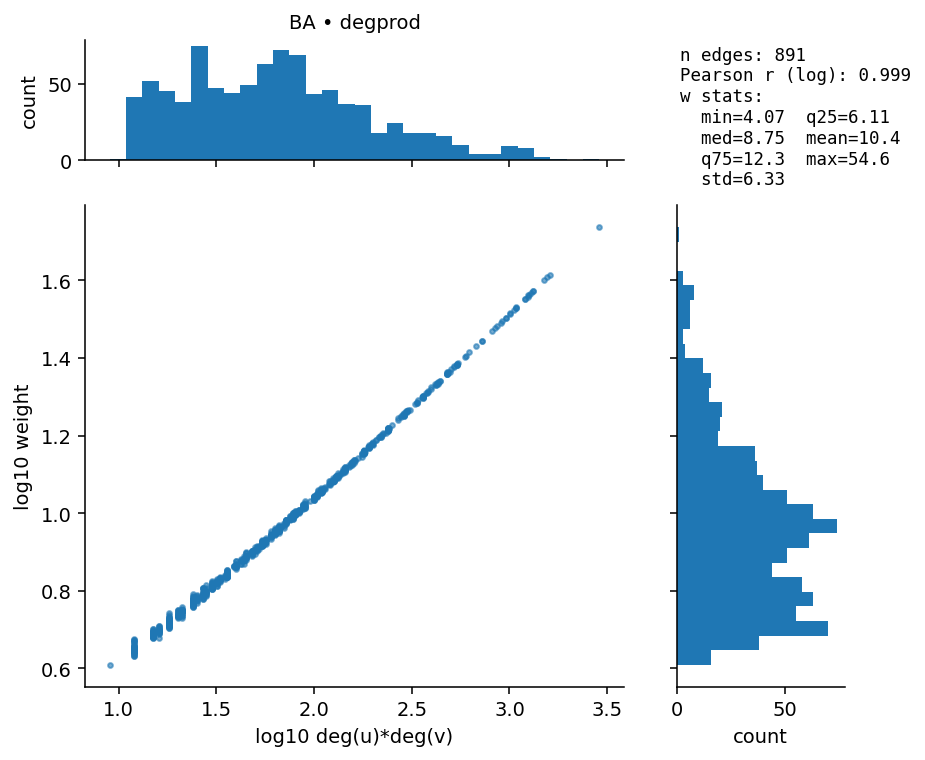

=== Node star inspection ===
node i = 3, degree k_i = 60, strength s_i = 1360.690480, alpha = 0.05
Local significance threshold p* = 0.049508
Top 10 neighbors by p_ij:
  (i,j)=(3,0)  p_ij=0.0402  alpha_ij=0.089093  w_ij=54.6396  keep? False
  (i,j)=(3,4)  p_ij=0.0302  alpha_ij=0.163946  w_ij=41.0696  keep? False
  (i,j)=(3,8)  p_ij=0.0298  alpha_ij=0.167654  w_ij=40.5692  keep? False
  (i,j)=(3,14)  p_ij=0.0293  alpha_ij=0.172778  w_ij=39.8954  keep? False
  (i,j)=(3,33)  p_ij=0.0275  alpha_ij=0.192646  w_ij=37.4565  keep? False
  (i,j)=(3,21)  p_ij=0.0275  alpha_ij=0.193402  w_ij=37.3687  keep? False
  (i,j)=(3,10)  p_ij=0.0268  alpha_ij=0.201348  w_ij=36.4653  keep? False
  (i,j)=(3,5)  p_ij=0.0262  alpha_ij=0.209290  w_ij=35.5968  keep? False
  (i,j)=(3,7)  p_ij=0.0250  alpha_ij=0.224718  w_ij=33.9983  keep? False
  (i,j)=(3,23)  p_ij=0.0249  alpha_ij=0.226257  w_ij=33.8448  keep? False


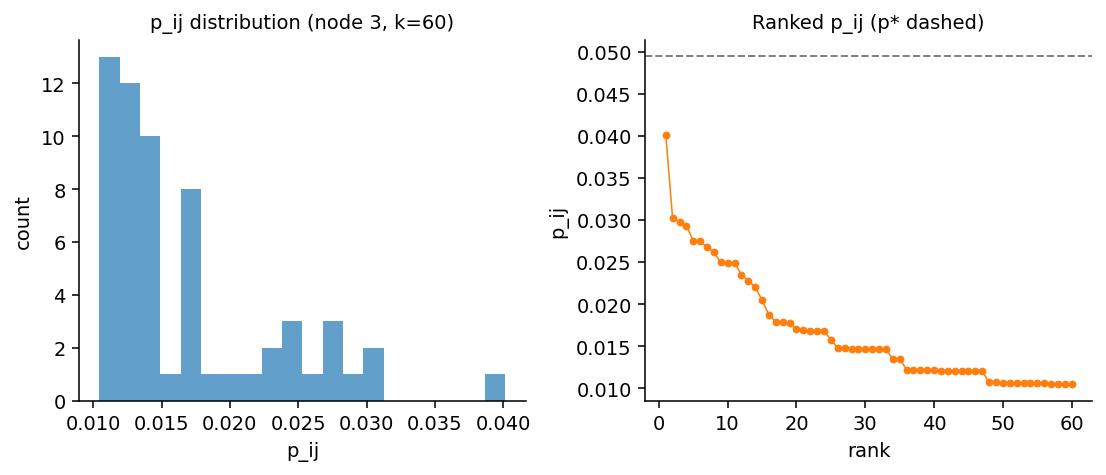


[GRAPH] ER | scheme=lognormal | directed=False
Nodes: 300, Edges: 915
Avg clustering: 0.0176
Weight stats: {'n': 915, 'min': 0.0387, 'q25': 0.4915, 'median': 0.9239, 'mean': 1.4365, 'q75': 1.7173, 'max': 13.0876, 'std': 1.6506}


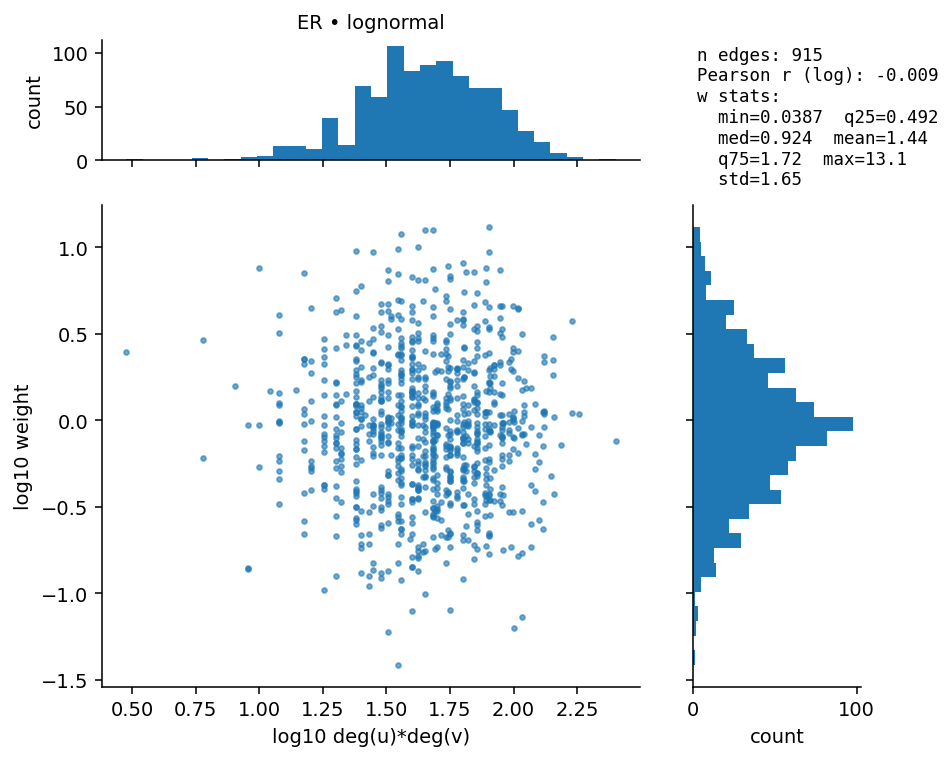

=== Node star inspection ===
node i = 106, degree k_i = 18, strength s_i = 17.491942, alpha = 0.05
Local significance threshold p* = 0.161566
Top 10 neighbors by p_ij:
  (i,j)=(106,60)  p_ij=0.2625  alpha_ij=0.005645  w_ij=4.5922  keep? True
  (i,j)=(106,99)  p_ij=0.0734  alpha_ij=0.273597  w_ij=1.2840  keep? False
  (i,j)=(106,288)  p_ij=0.0724  alpha_ij=0.278920  w_ij=1.2657  keep? False
  (i,j)=(106,76)  p_ij=0.0706  alpha_ij=0.288266  w_ij=1.2342  keep? False
  (i,j)=(106,269)  p_ij=0.0627  alpha_ij=0.332861  w_ij=1.0960  keep? False
  (i,j)=(106,101)  p_ij=0.0611  alpha_ij=0.342160  w_ij=1.0694  keep? False
  (i,j)=(106,61)  p_ij=0.0596  alpha_ij=0.351790  w_ij=1.0426  keep? False
  (i,j)=(106,36)  p_ij=0.0484  alpha_ij=0.430306  w_ij=0.8465  keep? False
  (i,j)=(106,70)  p_ij=0.0479  alpha_ij=0.434074  w_ij=0.8380  keep? False
  (i,j)=(106,160)  p_ij=0.0437  alpha_ij=0.468219  w_ij=0.7636  keep? False


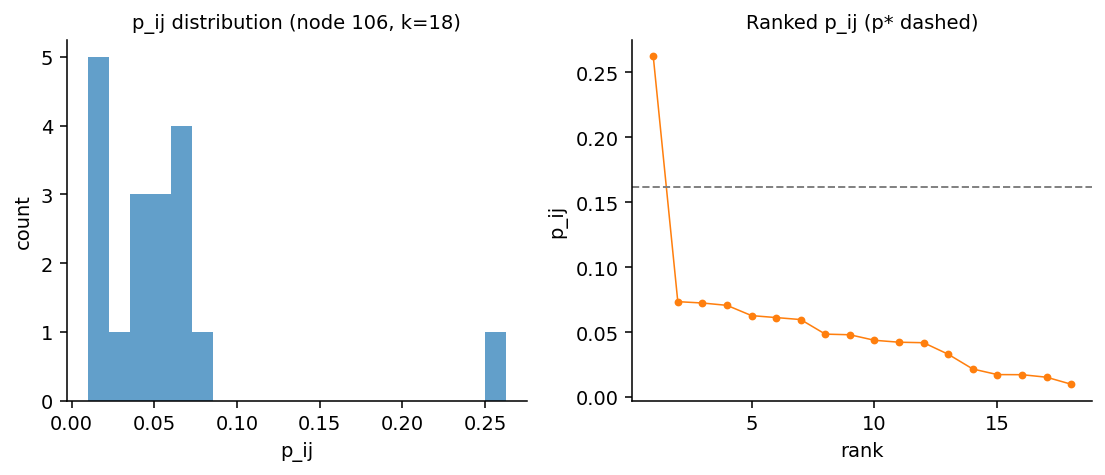


[GRAPH] WS | scheme=uniform | directed=False
Nodes: 300, Edges: 900
Avg clustering: 0.5293
Weight stats: {'n': 900, 'min': 0.5033, 'q25': 0.7454, 'median': 0.9901, 'mean': 0.9928, 'q75': 1.2488, 'max': 1.4991, 'std': 0.287}


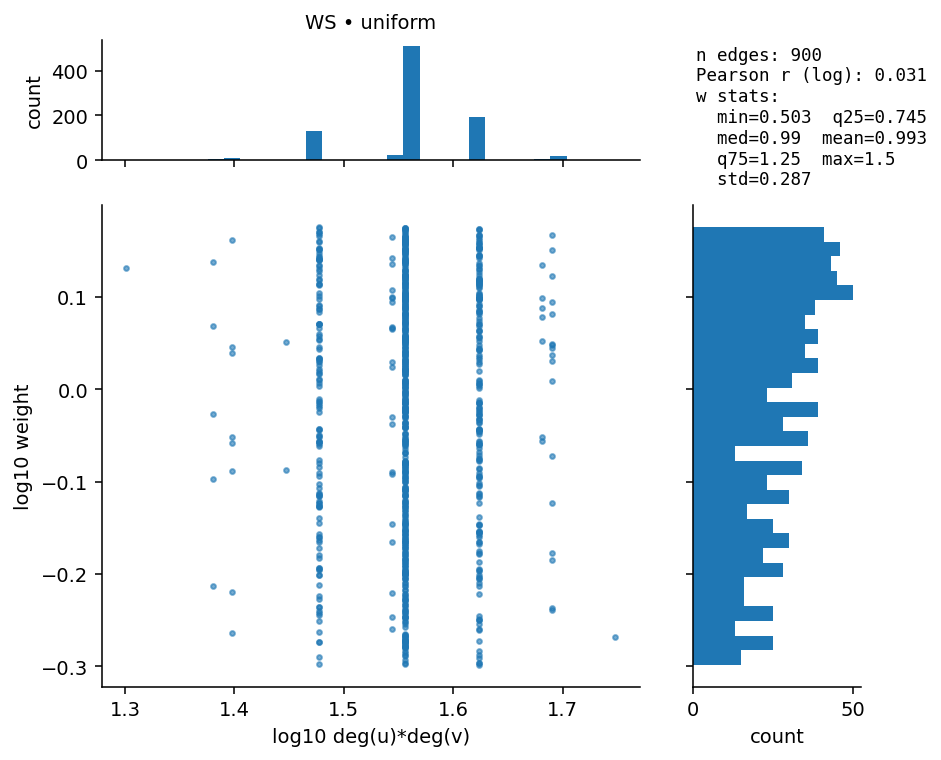

=== Node star inspection ===
node i = 210, degree k_i = 8, strength s_i = 8.477775, alpha = 0.05
Local significance threshold p* = 0.348164
Top 8 neighbors by p_ij:
  (i,j)=(210,208)  p_ij=0.1607  alpha_ij=0.293380  w_ij=1.3624  keep? False
  (i,j)=(210,209)  p_ij=0.1484  alpha_ij=0.324942  w_ij=1.2577  keep? False
  (i,j)=(210,212)  p_ij=0.1445  alpha_ij=0.335420  w_ij=1.2249  keep? False
  (i,j)=(210,213)  p_ij=0.1414  alpha_ij=0.344092  w_ij=1.1984  keep? False
  (i,j)=(210,207)  p_ij=0.1332  alpha_ij=0.367766  w_ij=1.1289  keep? False
  (i,j)=(210,262)  p_ij=0.1047  alpha_ij=0.461141  w_ij=0.8875  keep? False
  (i,j)=(210,211)  p_ij=0.1036  alpha_ij=0.465080  w_ij=0.8783  keep? False
  (i,j)=(210,64)  p_ij=0.0637  alpha_ij=0.631013  w_ij=0.5397  keep? False


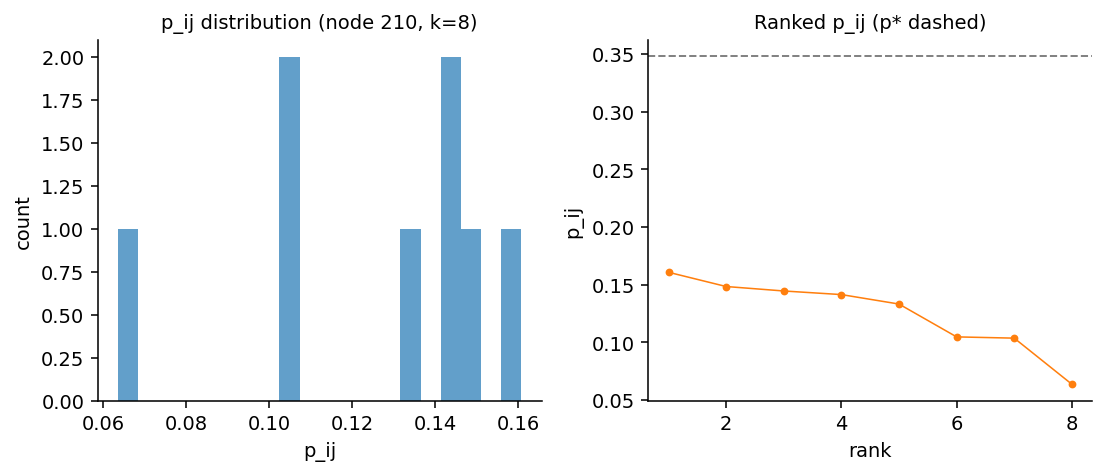


[GRAPH] Geometric | scheme=gravity | directed=False
Nodes: 300, Edges: 1812
Avg clustering: 0.6091
Weight stats: {'n': 1812, 'min': 227.6538, 'q25': 1703.437, 'median': 2506.7437, 'mean': 3425.4101, 'q75': 3653.1371, 'max': 53079.9281, 'std': 3906.5079}


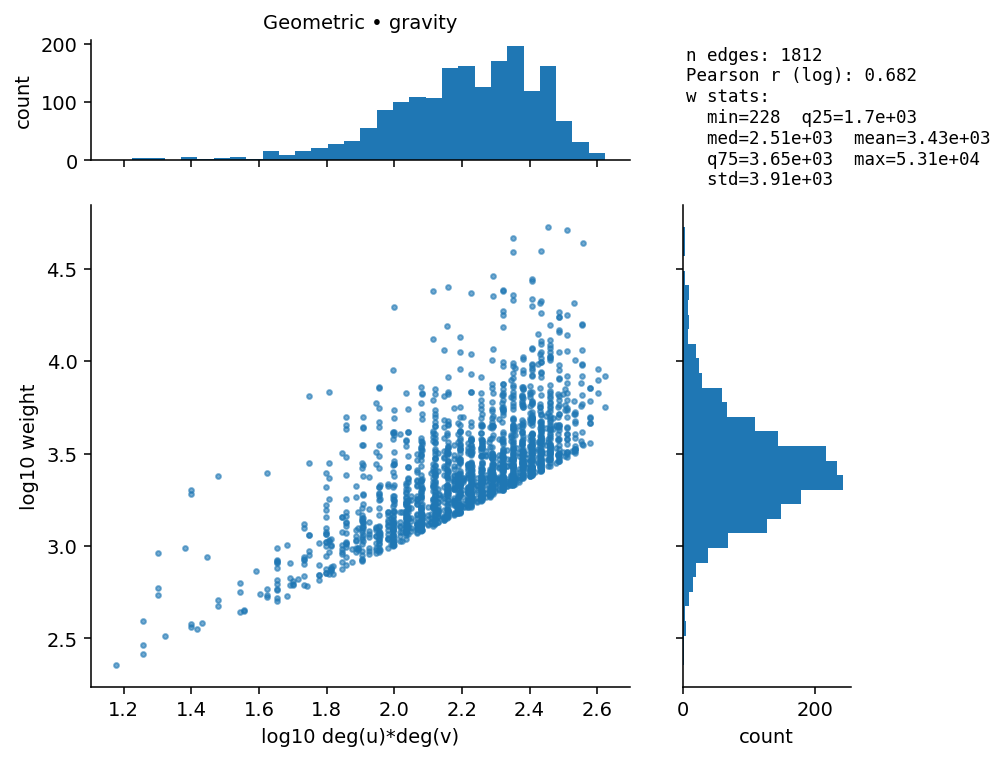

=== Node star inspection ===
node i = 31, degree k_i = 21, strength s_i = 104633.645231, alpha = 0.05
Local significance threshold p* = 0.139108
Top 10 neighbors by p_ij:
  (i,j)=(31,150)  p_ij=0.0863  alpha_ij=0.164401  w_ij=9031.7209  keep? False
  (i,j)=(31,267)  p_ij=0.0793  alpha_ij=0.191699  w_ij=8294.6069  keep? False
  (i,j)=(31,17)  p_ij=0.0725  alpha_ij=0.221941  w_ij=7586.4041  keep? False
  (i,j)=(31,209)  p_ij=0.0681  alpha_ij=0.243889  w_ij=7127.7331  keep? False
  (i,j)=(31,89)  p_ij=0.0643  alpha_ij=0.264768  w_ij=6726.4512  keep? False
  (i,j)=(31,86)  p_ij=0.0636  alpha_ij=0.268496  w_ij=6657.9740  keep? False
  (i,j)=(31,118)  p_ij=0.0550  alpha_ij=0.322747  w_ij=5752.2773  keep? False
  (i,j)=(31,198)  p_ij=0.0542  alpha_ij=0.328138  w_ij=5670.3364  keep? False
  (i,j)=(31,166)  p_ij=0.0476  alpha_ij=0.377184  w_ij=4978.6595  keep? False
  (i,j)=(31,135)  p_ij=0.0469  alpha_ij=0.382409  w_ij=4910.0890  keep? False


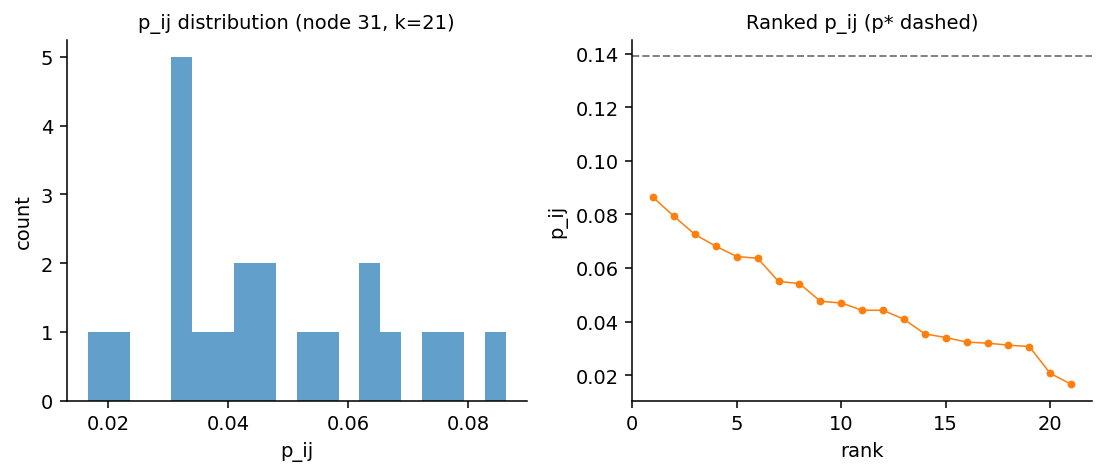


[GRAPH] SBM | scheme=pareto | directed=False
Nodes: 360, Edges: 1304
Avg clustering: 0.0432
Weight stats: {'n': 1304, 'min': 1.001, 'q25': 1.2233, 'median': 1.5892, 'mean': 2.7733, 'q75': 2.5159, 'max': 125.4231, 'std': 5.638}


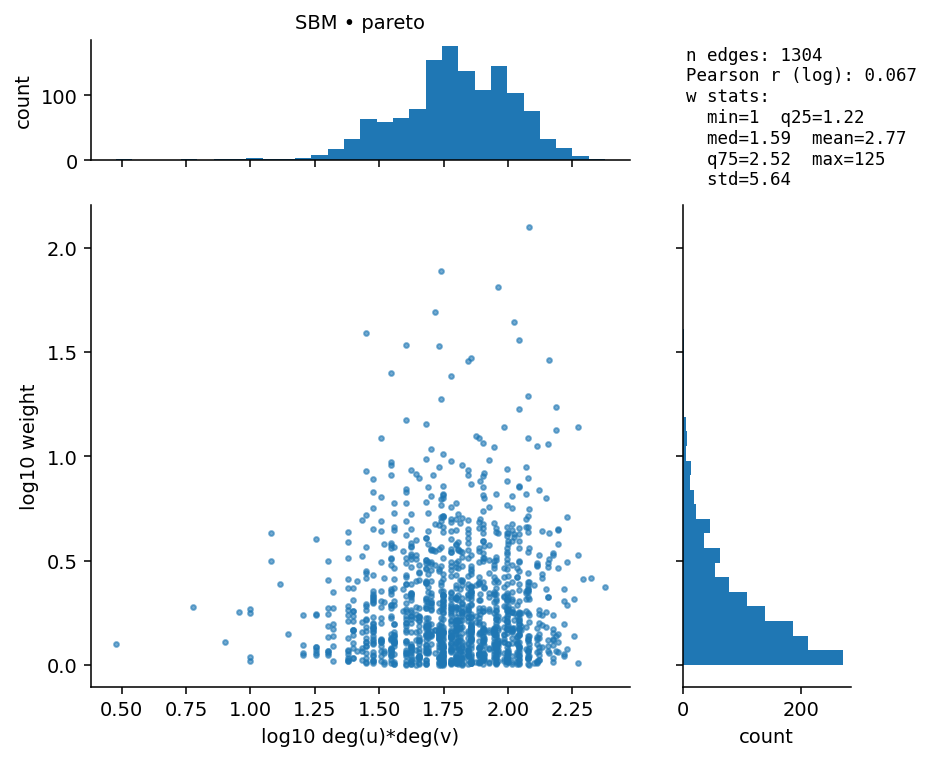

=== Node star inspection ===
node i = 271, degree k_i = 17, strength s_i = 58.728869, alpha = 0.05
Local significance threshold p* = 0.170750
Top 10 neighbors by p_ij:
  (i,j)=(271,351)  p_ij=0.2356  alpha_ij=0.013597  w_ij=13.8344  keep? True
  (i,j)=(271,275)  p_ij=0.1389  alpha_ij=0.091384  w_ij=8.1573  keep? False
  (i,j)=(271,302)  p_ij=0.0869  alpha_ij=0.233559  w_ij=5.1027  keep? False
  (i,j)=(271,304)  p_ij=0.0783  alpha_ij=0.271383  w_ij=4.5973  keep? False
  (i,j)=(271,102)  p_ij=0.0602  alpha_ij=0.370570  w_ij=3.5331  keep? False
  (i,j)=(271,323)  p_ij=0.0574  alpha_ij=0.388334  w_ij=3.3713  keep? False
  (i,j)=(271,286)  p_ij=0.0471  alpha_ij=0.461830  w_ij=2.7683  keep? False
  (i,j)=(271,301)  p_ij=0.0464  alpha_ij=0.467313  w_ij=2.7270  keep? False
  (i,j)=(271,340)  p_ij=0.0404  alpha_ij=0.517262  w_ij=2.3705  keep? False
  (i,j)=(271,335)  p_ij=0.0399  alpha_ij=0.521452  w_ij=2.3421  keep? False


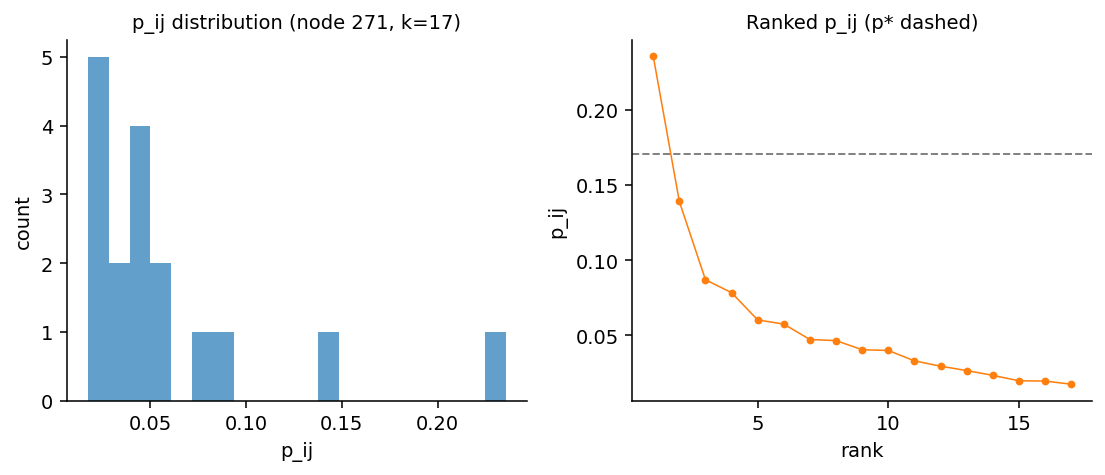

In [ ]:
# ===========================
#  runner
# ===========================
def run_selected_demo(seed=7, alpha=0.05, max_rows=10,
                      do_compact_panel=True, do_star_inspect=True):
    """
    Runs a small, diverse set of (graph, weighting) examples:
      1) BA × degprod
      2) ER × lognormal
      3) WS × uniform
      4) Geometric × gravity
      5) SBM × pareto
    Uses compact scatter+marginals and the local-star check for undirected graphs.
    """
    suite = make_suite(seed=seed)

    selections = [
        ("BA",        "degprod"),    # hubs -> larger deg(u)*deg(v), weight tracks structure
        ("ER",        "lognormal"),  # heavy-tailed weights independent of degrees
        ("WS",        "uniform"),    # flat weights to expose small-world topology
        ("Geometric", "gravity"),    # spatial decay; expect weaker ties across space
        ("SBM",       "pareto"),     # bursty weights emphasize block structure
    ]

    for name, scheme in selections:
        if name not in suite:
            print(f"[skip] {name} not in suite")
            continue

        G = suite[name].copy()
        assign_weights(G, scheme=scheme, seed=seed)

        directed = G.is_directed()
        n, m = G.number_of_nodes(), G.number_of_edges()
        try:
            cbar = (nx.average_clustering(G) if not directed else None)
        except Exception:
            cbar = None

        # Basic stats
        w = _edge_weights(G)
        x = _degprod_array(G)
        wstats = _basic_stats(w)

        print(f"\n[GRAPH] {name} | scheme={scheme} | directed={directed}")
        print(f"Nodes: {n}, Edges: {m}")
        print("Avg clustering:", ("—" if directed else f"{cbar:.4f}" if cbar is not None else "n/a"))
        print("Weight stats:",
              {k: (round(v,4) if isinstance(v,(int,float)) and np.isfinite(v) else v)
               for k,v in wstats.items()})

        # Compact panel (scatter + marginals + stats)
        if do_compact_panel and m > 0:
            scatter_with_marginals(
                x, w,
                title=f"{name} • {scheme}",
                xlabel="deg(u)*deg(v)",
                ylabel="weight",
                loglog=True,
                bins=30
            )

        # Local star inspection for undirected
        if do_star_inspect and not directed and m > 0:
            inspect_node_star(G, node=None, alpha=alpha, max_rows=max_rows, weight="weight", seed=seed)

# ---------------------------
# How to run (uncomment):
# ---------------------------
run_selected_demo(
    seed=7,           # keep reproducible
    alpha=0.05,
    max_rows=10,
    do_compact_panel=True,
    do_star_inspect=True
)

> Seeing how topology and weights interact helps reveal what the **disparity filter** really tests: *does one link stand out as abnormally strong in its local context?*

> Below, each combo shows how different network “worlds” behave under this question — and how the filter reacts to the local balance of power.

---

### **1️⃣ BA × degprod → “Structure drives weights”**

**What the scatter shows**

* Perfect log–log line: $w \propto k_u k_v$.
* Pearson $r_{log}=0.999$ → complete structural correlation.

**Node-level view**

* Node 3, degree 60: all normalized shares $p_{ij}$ cluster tightly around 0.02–0.03.
* Local threshold $p^*=0.0495$ → none significant.

> When weights are fully determined by degree, *no edge is exceptional*.
> The filter prunes everything — hubs share their load evenly.
> Think of a “rich-club” where every road is proportionally busy: structurally impressive but statistically dull.

**Lesson**

> The disparity filter ignores *global importance* and focuses on *local surprise*. A hub’s many heavy edges aren’t surprising if every connection is equally strong.

---

### **2️⃣ ER × lognormal → “Weights uncorrelated with topology”**

**What the scatter shows**

* Cloud-like scatter: no relation ($r≈0$).
* Weights are random → high variance.

**Node-level view**

* Node 106 (k=18): one edge $p_{ij}=0.26 > p^*=0.16$ → **significant**.

**Interpretation**

> Random weights create uneven load splits. The filter identifies the few *accidental outliers* — edges that take an unexpectedly large share of a node’s total strength.

**Lesson**

> Even in random systems, disparity can create an emergent *backbone of lucky winners*. The filter becomes a detector of chance dominance.

---

### **3️⃣ WS × uniform → “Regular structure, flat weights”**

**What the scatter shows**

* Very narrow vertical stripes: nearly identical degrees, uniform weights.
* Pearson correlation near zero.

**Node-level view**

* Node 210 (k=8): all $p_{ij}\approx0.1$–0.16, none exceed $p^*=0.35$.

**Interpretation**

> In a perfectly regular lattice, everything looks the same.
> The disparity filter removes all edges — *no local surprises*, just smooth balance.

**Lesson**

> Homogeneity suppresses significance. The filter thrives on diversity: when all weights are similar, there’s no “standout” edge to keep.

---

### **4️⃣ Geometric × gravity → “Spatial + degree interplay”**

**What the scatter shows**

* Moderate positive trend ($r≈0.68$).
* $w \propto (k_u k_v)/d_{uv}^2$ mixes degree and geometry.

**Node-level view**

* Node 31 (k=21): smooth gradient of $p_{ij}$, all below $p^*=0.14$.

**Interpretation**

> Weights reflect distances smoothly → no edge dominates.
> Geometry regularizes disparity, yielding few or no significant ties.

**Lesson**

> Spatial embedding limits randomness — nodes split their load predictably with neighbors. The disparity filter confirms that *geometry enforces homogeneity*.

---

### **5️⃣ SBM × Pareto → “Community structure + heavy tails”**

**What the scatter shows**

* Weak correlation ($r≈0.07$), but huge weight variance due to Pareto tail.
* A few extreme links dominate the node’s total strength.

**Node-level view**

* Node 271 (k=17): one edge $p_{ij}=0.236>p^*=0.17$ survives — the clear winner.

**Interpretation**

> Communities impose modular structure; Pareto weights add heavy-tailed randomness.
> The disparity filter isolates the few truly dominant or bridging ties — *the backbone essence*.

**Lesson**

> This is where the disparity filter shines: the system has both structure (blocks) and noise (heavy tails). It keeps edges that are *statistically surprising and topologically meaningful*.

> The disparity filter is not about “strongest links” but about *statistically unexpected ones*. It preserves edges that carry more weight than a fair split would predict, keeping all scales where surprise emerges.

In [ ]:
# =========================================
# Disparity Filter — Alpha Sweep Helper
# =========================================
import numpy as np
import matplotlib.pyplot as plt

def _weight_sum(G, weight="weight"):
    return sum(d.get(weight,1.0) for *_, d in G.edges(data=True))

def _fraction_weight_kept(G, B, weight="weight"):
    tot = _weight_sum(G, weight)
    kept = _weight_sum(B, weight)
    return 0.0 if tot == 0 else kept / tot

def _giant_component_size(G):
    if G.number_of_nodes() == 0:
        return 0
    if G.is_directed():
        comps = nx.strongly_connected_components(G)
    else:
        comps = nx.connected_components(G)
    return max((len(c) for c in comps), default=0)

def run_alpha_sweep(
    G,
    alphas=(0.5, 0.1, 0.05, 0.01, 1e-3),
    rule="or",
    weight="weight",
    debug=False,
    return_as="list"  # "list" or "dataframe"
):
    """
    Sweep over alpha values for the disparity filter and visualize retention.
    Returns a list of dicts (or a pandas DataFrame if return_as='dataframe').

    Metrics per alpha:
      - edges_kept_frac, weight_kept_frac
      - edges_kept, nodes_with_edges (backbone)
      - giant_component_size_before/after
      - avg_clustering_before/after (undirected only)
      - mean_degree_before/after
    """
    alphas = sorted(alphas, reverse=False)
    N = G.number_of_nodes()
    E = G.number_of_edges()
    undirected = not G.is_directed()

    # Precompute baseline metrics
    gc_before = _giant_component_size(G)
    try:
        c_before = nx.average_clustering(G) if undirected else np.nan
    except Exception:
        c_before = np.nan
    mean_deg_before = (2*E / max(1, N)) if undirected else (E / max(1, N))

    rows = []
    for a in alphas:
        B = disparity_filter(G, alpha=a, rule=rule, weight=weight, debug=debug)
        eB = B.number_of_edges()
        edges_kept_frac = eB / max(1, E)
        weight_kept_frac = _fraction_weight_kept(G, B, weight)

        n_nodes_w_edges = sum(1 for v in B if B.degree(v) > 0)
        gc_after = _giant_component_size(B)
        try:
            c_after = nx.average_clustering(B) if undirected else np.nan
        except Exception:
            c_after = np.nan
        mean_deg_after = (2*eB / max(1, B.number_of_nodes())) if undirected else (eB / max(1, B.number_of_nodes()))

        rows.append(dict(
            alpha=a,
            edges_kept=eB,
            edges_kept_frac=edges_kept_frac,
            weight_kept_frac=weight_kept_frac,
            nodes_with_edges=n_nodes_w_edges,
            gc_before=gc_before,
            gc_after=gc_after,
            clustering_before=c_before,
            clustering_after=c_after,
            mean_degree_before=mean_deg_before,
            mean_degree_after=mean_deg_after
        ))

    if return_as == "dataframe":
        try:
            import pandas as pd
            return pd.DataFrame(rows)
        except Exception:
            # fall back gracefully if pandas isn't available
            return rows
    return rows

# ---------------------------
# Example usage (uncomment):
# ---------------------------
sweep = run_alpha_sweep(
    G,
    alphas=(0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001),
    rule="or",
    weight="weight",
    debug=False,
    return_as="dataframe"   # or "list"
)
sweep

,alpha,edges_kept,edges_kept_frac,weight_kept_frac,nodes_with_edges,gc_before,gc_after,clustering_before,clustering_after,mean_degree_before,mean_degree_after
0,0.001,3,0.003367,0.023419,6,300,2,0.064123,0.000000,5.94,0.020000
1,0.005,13,0.014590,0.093918,25,300,3,0.064123,0.000000,5.94,0.086667
2,0.010,21,0.023569,0.126120,40,300,3,0.064123,0.000000,5.94,0.140000
3,0.020,38,0.042649,0.192626,67,300,6,0.064123,0.000000,5.94,0.253333
4,0.050,70,0.078563,0.293558,114,300,9,0.064123,0.000000,5.94,0.466667
5,0.100,121,0.135802,0.416958,175,300,21,0.064123,0.000000,5.94,0.806667
6,0.200,214,0.240180,0.572243,251,300,129,0.064123,0.000000,5.94,1.426667
7,0.500,510,0.572391,0.856281,300,300,300,0.064123,0.027457,5.94,3.400000


## α-Sweep Full Pipeline

This module provides a systematic mechanism to evaluate how the disparity filter behaves across multiple α thresholds. It quantifies what fraction of the network’s edges and total weight remain as the filtering threshold becomes more selective, and simultaneously monitors how key structural properties evolve (connectivity, clustering, mean degree).

In the broader setup, it acts as the transition point between the theoretical definition of backbone extraction and the empirical interpretation of sparsification behavior. It also supports multi‑graph comparison and automated reporting for scalability.

The α‑sweep acts as the diagnostic microscope of the backbone extraction process:

It identifies the α region where weight retention stays high but edge count significantly drops.

It highlights when structure collapses (GCC fragmentation or clustering decay), warning about over‑pruning.

It reveals stable multiscale zones suitable for robust backbone modeling.

These insights directly inform the backbone selection criteria applied later in the pipeline.

In [ ]:
# =========================================
# Disparity Filter — α-sweep full pipeline
# =========================================

selections = [
    ("BA",        "degprod"),   # scale-free, structural w ~ deg(i)deg(j)
    ("ER",        "lognormal"), # random topology, heavy-tailed independent weights
    ("WS",        "uniform"),   # small-world, flat weights emphasize topology
    ("Geometric", "gravity"),   # spatial decay; +corr with degprod, −corr with distance
    ("SBM",       "pareto"),    # communities with bursty weights
]

# ---------------------------
# Suite builder (graphs)
# ---------------------------
def make_default_suite(
    n=600,
    seed=42,
    *,
    ba_m=3,
    er_p=0.01,
    ws_k=8,
    ws_p=0.05,
    geo_radius=0.08,
    sbm_blocks=(200, 200, 200),
    sbm_p_in=0.03,
    sbm_p_out=0.003,
):
    rng = np.random.default_rng(seed)
    random.seed(seed)

    # BA
    G_ba = nx.barabasi_albert_graph(n, ba_m, seed=seed)

    # ER
    G_er = nx.erdos_renyi_graph(n, er_p, seed=seed)

    # WS (connectedness not guaranteed for some params, but fine for sweep)
    G_ws = nx.watts_strogatz_graph(n, ws_k, ws_p, seed=seed)

    # Geometric (store positions)
    G_geo = nx.random_geometric_graph(n, geo_radius, seed=seed)
    if not nx.get_node_attributes(G_geo, "pos"):
        pos = {v: rng.random(2) for v in G_geo.nodes()}
        nx.set_node_attributes(G_geo, pos, "pos")

    # SBM (3-block by default)
    sizes = list(sbm_blocks)
    k = len(sizes)
    P = np.full((k, k), sbm_p_out, dtype=float)
    np.fill_diagonal(P, sbm_p_in)
    G_sbm = nx.stochastic_block_model(sizes, P, seed=seed)
    # Relabel to 0..n-1 to match other graphs
    G_sbm = nx.convert_node_labels_to_integers(G_sbm, first_label=0)

    # Return as dict
    return {
        "BA": G_ba,
        "ER": G_er,
        "WS": G_ws,
        "Geometric": G_geo,
        "SBM": G_sbm,
    }

In [ ]:
# ---------------------------
# Weighting schemes
# ---------------------------
def _safe_degree(G, v):
    # works for DiGraph/Graph (uses in-degree+out-degree for DiGraph)
    if G.is_directed():
        return G.in_degree(v) + G.out_degree(v)
    return G.degree(v)

def assign_weights(G, scheme="degprod", seed=42, weight="weight"):
    """
    Mutates G in-place, setting edge attribute `weight`.
    Supported schemes: degprod, lognormal, uniform, gravity, pareto
    """
    rng = np.random.default_rng(seed)

    if scheme == "degprod":
        # w_ij ∝ (deg(i)*deg(j)) with small noise to avoid ties
        for u, v in G.edges():
            w = (_safe_degree(G, u) + 1) * (_safe_degree(G, v) + 1)
            w = float(w) + 1e-3 * rng.random()
            G[u][v][weight] = w

    elif scheme == "lognormal":
        # independent heavy-tailed weights
        for u, v in G.edges():
            G[u][v][weight] = float(rng.lognormal(mean=0.0, sigma=1.0))

    elif scheme == "uniform":
        # Flat weights emphasize topology (use all ones)
        for u, v in G.edges():
            G[u][v][weight] = 1.0

    elif scheme == "gravity":
        # w_ij ∝ (deg(i)*deg(j)) / (dist(u,v)^beta + eps)
        beta = 1.5
        eps = 1e-6
        pos = nx.get_node_attributes(G, "pos")
        if not pos:
            # if positions missing, create random 2D in [0,1]^2
            pos = {v: rng.random(2) for v in G.nodes()}
            nx.set_node_attributes(G, pos, "pos")

        for u, v in G.edges():
            du = np.array(pos[u]); dv = np.array(pos[v])
            dist = np.linalg.norm(du - dv)
            base = (_safe_degree(G, u) + 1) * (_safe_degree(G, v) + 1)
            w = base / (dist**beta + eps)
            G[u][v][weight] = float(w)

    elif scheme == "pareto":
        # bursty: Pareto(α) shifted/scaled
        alpha = 2.0
        for u, v in G.edges():
            # Pareto with xm=1
            w = (1.0 / (rng.random() ** (1.0 / alpha)))
            G[u][v][weight] = float(w)
    else:
        raise ValueError(f"Unknown scheme: {scheme}")

In [ ]:
# ---------------------------
# Alpha sweep 
# ---------------------------
def run_alpha_sweep(
    G,
    alphas=(0.5, 0.1, 0.05, 0.01, 1e-3),
    rule="or",
    weight="weight",
    debug=False,
    return_as="list"  # "list" or "dataframe"
):
    alphas = sorted(alphas, reverse=False)
    N = G.number_of_nodes()
    E = G.number_of_edges()
    undirected = not G.is_directed()

    # Precompute baseline metrics
    gc_before = _giant_component_size(G)
    try:
        c_before = nx.average_clustering(G) if undirected else np.nan
    except Exception:
        c_before = np.nan
    mean_deg_before = (2 * E / max(1, N)) if undirected else (E / max(1, N))

    rows = []
    for a in alphas:
        B = disparity_filter(G, alpha=a, rule=rule, weight=weight, debug=debug)
        eB = B.number_of_edges()
        edges_kept_frac = eB / max(1, E)
        weight_kept_frac = _fraction_weight_kept(G, B, weight)

        n_nodes_w_edges = sum(1 for v in B if B.degree(v) > 0)
        gc_after = _giant_component_size(B)
        try:
            c_after = nx.average_clustering(B) if undirected else np.nan
        except Exception:
            c_after = np.nan
        mean_deg_after = (
            (2 * eB / max(1, B.number_of_nodes()))
            if undirected
            else (eB / max(1, B.number_of_nodes()))
        )

        rows.append(dict(
            alpha=a,
            edges_kept=eB,
            edges_kept_frac=edges_kept_frac,
            weight_kept_frac=weight_kept_frac,
            nodes_with_edges=n_nodes_w_edges,
            gc_before=gc_before,
            gc_after=gc_after,
            clustering_before=c_before,
            clustering_after=c_after,
            mean_degree_before=mean_deg_before,
            mean_degree_after=mean_deg_after
        ))

    if return_as == "dataframe":
        try:
            import pandas as pd
            return pd.DataFrame(rows)
        except Exception:
            return rows
    return rows


In [ ]:
# ---------------------------
# Quick report
# ---------------------------
def run_disparity_filter_report(G, alpha=0.1, rule="or", weight="weight", debug=False, title_tag=None):
    B = disparity_filter(G, alpha=alpha, rule=rule, weight=weight, debug=debug)
    E = G.number_of_edges()
    eB = B.number_of_edges()
    frac_e = eB / max(1, E)
    frac_w = _fraction_weight_kept(G, B, weight)
    title = title_tag or f"Backbone (alpha={alpha}, rule={rule})"
    print(f"[report] {title}: edges kept {eB}/{E} ({frac_e:.3f}), weight kept {frac_w:.3f}")
    return B

# ---------------------------
# Plotting for α-sweep
# ---------------------------
def plot_alpha_sweep(results, show_table=True, max_rows=10):
    """
    Plot key alpha-sweep metrics for each (network, scheme) pair
    and optionally display the numeric DataFrame below each plot.
    """

    try:
        import pandas as pd
    except Exception:
        pd = None

    for (name, scheme), df in results.items():
        if not hasattr(df, "plot"):
            if pd is None:
                raise RuntimeError("Pandas required for plotting lists; or return_as='dataframe'.")
            df = pd.DataFrame(df)

        if df.empty:
            print(f"[warn] Empty sweep for {name} × {scheme} — skipping plot.")
            continue

        alphas = df["alpha"].values

        # --- 4-panel plot ---
        plt.figure(figsize=(10, 6))
        plt.suptitle(f"{name} × {scheme} — Disparity α-sweep", fontsize=14, weight="bold")

        # 1) Fraction kept
        plt.subplot(2, 2, 1)
        plt.plot(alphas, df["edges_kept_frac"], "o-", label="Edges kept")
        plt.plot(alphas, df["weight_kept_frac"], "s--", label="Weight kept")
        plt.xscale("log")
        plt.xlabel("α (log scale)")
        plt.ylabel("Fraction kept")
        plt.legend()
        plt.grid(alpha=0.3)

        # 2) Giant component ratio
        plt.subplot(2, 2, 2)
        denom = np.where(df["gc_before"].to_numpy() == 0, np.nan, df["gc_before"].to_numpy())
        ratio = df["gc_after"].to_numpy() / denom
        plt.plot(alphas, ratio, "o-")
        plt.xscale("log")
        plt.ylabel("GC size ratio (after/before)")
        plt.xlabel("α (log scale)")
        plt.grid(alpha=0.3)

        # 3) Clustering
        plt.subplot(2, 2, 3)
        plt.plot(alphas, df["clustering_after"], "o-", label="after")
        try:
            base_c = float(df["clustering_before"].iloc[0])
            if not math.isnan(base_c):
                plt.axhline(base_c, ls="--", color="gray", label="before")
        except Exception:
            pass
        plt.xscale("log")
        plt.xlabel("α (log scale)")
        plt.ylabel("Avg. clustering")
        plt.legend()
        plt.grid(alpha=0.3)

        # 4) Mean degree
        plt.subplot(2, 2, 4)
        plt.plot(alphas, df["mean_degree_after"], "o-", label="after")
        try:
            base_md = float(df["mean_degree_before"].iloc[0])
            if not math.isnan(base_md):
                plt.axhline(base_md, ls="--", color="gray", label="before")
        except Exception:
            pass
        plt.xscale("log")
        plt.xlabel("α (log scale)")
        plt.ylabel("Mean degree")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

        # --- Display numeric DataFrame below the plot ---
        if show_table:
            display_cols = [
                "alpha", "edges_kept_frac", "weight_kept_frac",
                "gc_after", "clustering_after", "mean_degree_after"
            ]
            _df = df[display_cols].copy()
            _df = _df.round(4)

            print(f"\n**{name} × {scheme} — α-sweep numeric summary:**")
            from IPython.display import display
            if len(_df) > max_rows:
                display(_df.head(max_rows))
                print(f"... ({len(_df) - max_rows} more rows)")
            else:
                display(_df)


In [ ]:
# ---------------------------
# Suite runner
# ---------------------------
def run_disparity_alpha_sweep_suite(
    selections,
    suite,
    *,
    alphas=(0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001),
    rule="or",
    weight="weight",
    seed=42,
    do_report=True,
    do_sweep=True,
    debug=False,
    return_as="dataframe",
):
    results = {}
    for name, scheme in selections:
        if name not in suite:
            print(f"[skip] {name} not in suite")
            continue

        print("\n" + "=" * 72)
        print(f"{name} × {scheme} — disparity backbone + α-sweep")
        print("=" * 72)

        # Build and weight the graph
        G = suite[name].copy()
        assign_weights(G, scheme=scheme, seed=seed)

        # 1) One-shot backbone report at first α
        if do_report:
            a0 = alphas[0] if isinstance(alphas, (list, tuple)) else float(alphas)
            _title = f"{name} • {scheme} backbone (alpha={a0}, rule={rule})"
            try:
                _ = run_disparity_filter_report(
                    G, alpha=a0, rule=rule, weight=weight, debug=debug, title_tag=_title
                )
            except Exception as e:
                print(f"[warn] report failed for {name} × {scheme} at α={a0}: {e}")

        # 2) α-sweep
        if do_sweep:
            try:
                sweep_df_or_list = run_alpha_sweep(
                    G,
                    alphas=alphas,
                    rule=rule,
                    weight=weight,
                    debug=False,
                    return_as=return_as
                )
                results[(name, scheme)] = sweep_df_or_list
            except Exception as e:
                print(f"[warn] α-sweep failed for {name} × {scheme}: {e}")

    return results



BA × degprod — disparity backbone + α-sweep
[report] BA • degprod backbone (alpha=0.5, rule=or): edges kept 1218/1791 (0.680), weight kept 0.931

ER × lognormal — disparity backbone + α-sweep
[report] ER • lognormal backbone (alpha=0.5, rule=or): edges kept 1029/1774 (0.580), weight kept 0.873

WS × uniform — disparity backbone + α-sweep
[report] WS • uniform backbone (alpha=0.5, rule=or): edges kept 2400/2400 (1.000), weight kept 1.000

Geometric × gravity — disparity backbone + α-sweep
[report] Geometric • gravity backbone (alpha=0.5, rule=or): edges kept 1946/3299 (0.590), weight kept 0.858

SBM × pareto — disparity backbone + α-sweep
[report] SBM • pareto backbone (alpha=0.5, rule=or): edges kept 1651/2146 (0.769), weight kept 0.867


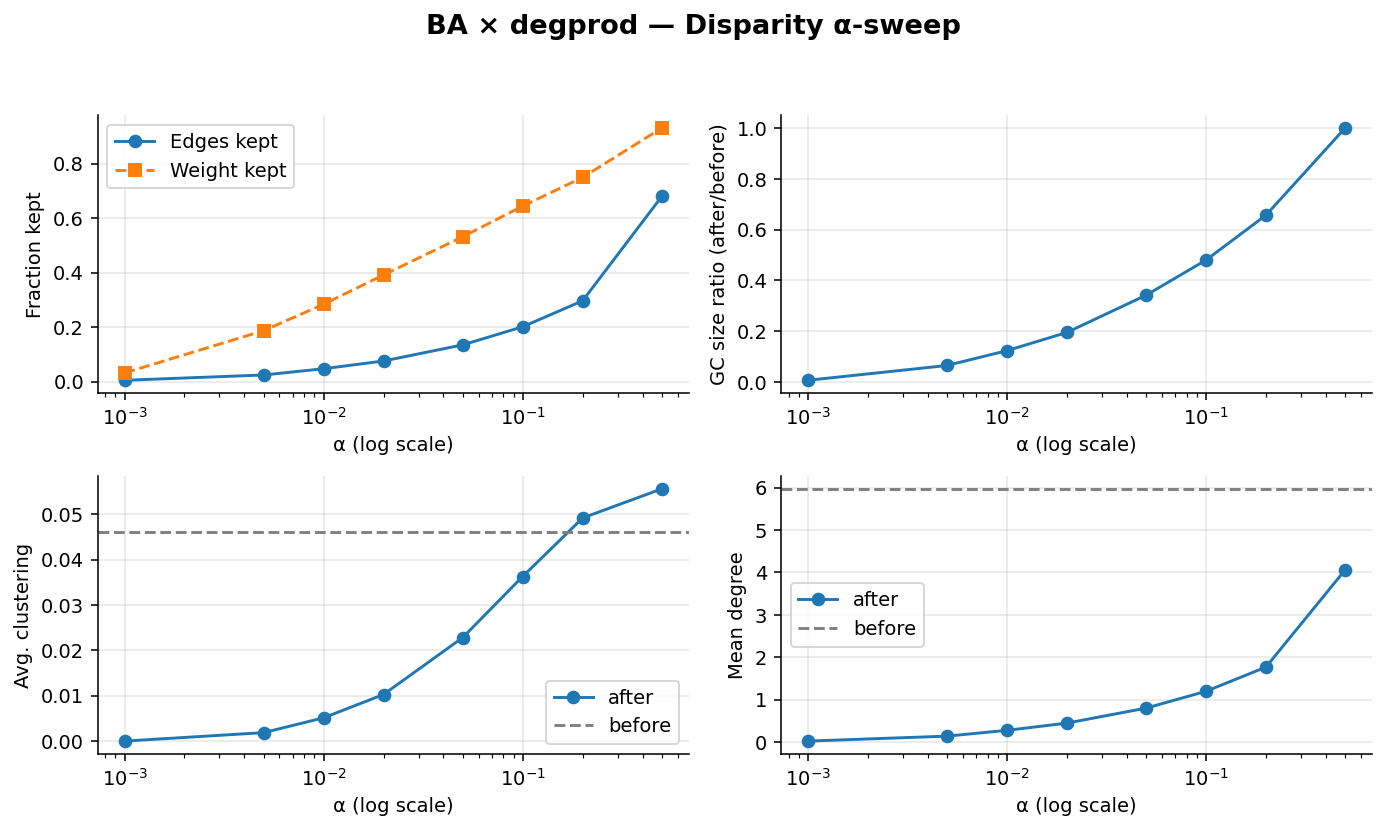


**BA × degprod — α-sweep numeric summary:**


,alpha,edges_kept_frac,weight_kept_frac,gc_after,clustering_after,mean_degree_after
0,0.001,0.0045,0.0313,4,0.0000,0.0267
1,0.005,0.0240,0.1868,39,0.0019,0.1433
2,0.010,0.0469,0.2838,74,0.0051,0.2800
3,0.020,0.0754,0.3915,117,0.0103,0.4500
4,0.050,0.1346,0.5319,205,0.0228,0.8033
5,0.100,0.2010,0.6443,288,0.0363,1.2000
6,0.200,0.2965,0.7497,394,0.0492,1.7700
7,0.500,0.6801,0.9312,600,0.0556,4.0600


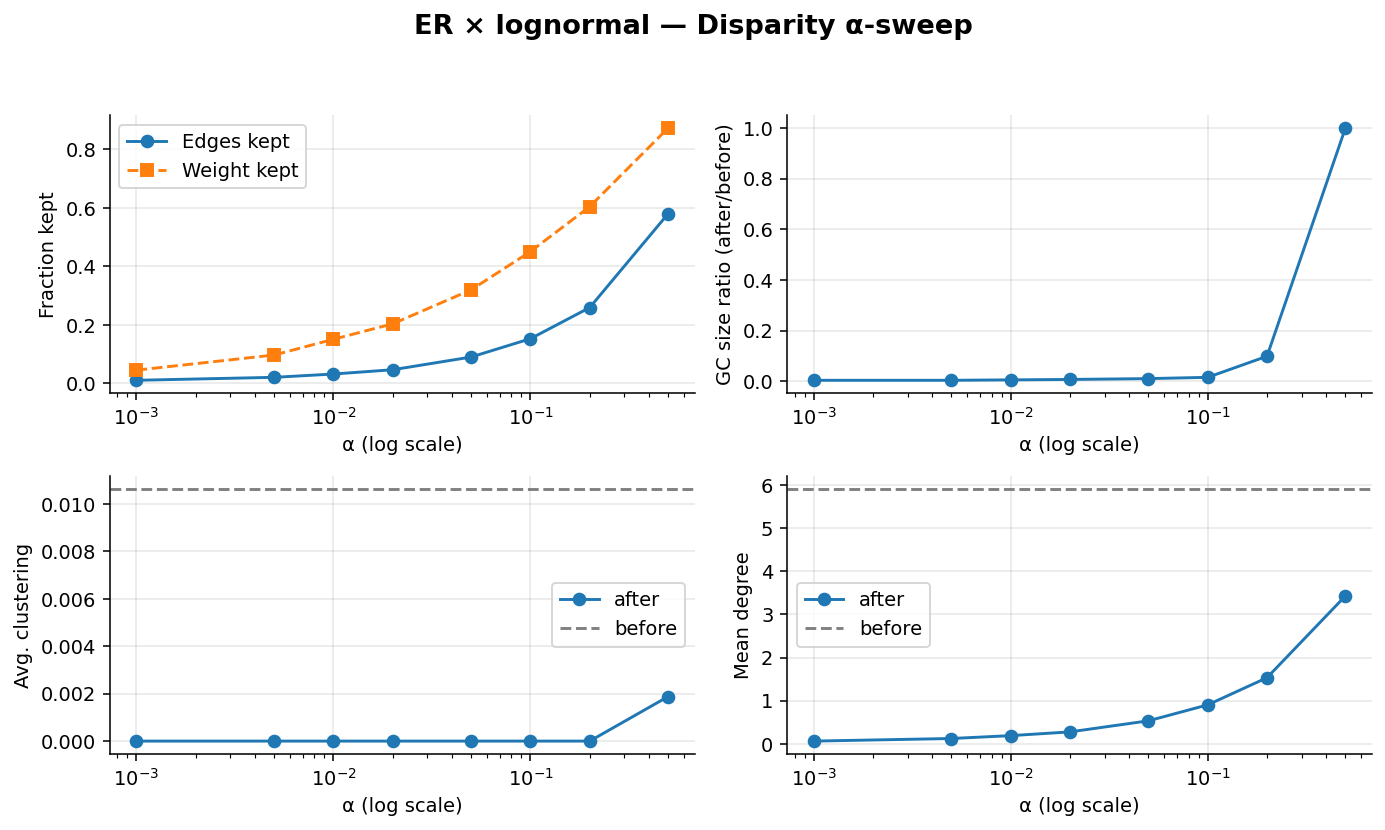


**ER × lognormal — α-sweep numeric summary:**


,alpha,edges_kept_frac,weight_kept_frac,gc_after,clustering_after,mean_degree_after
0,0.001,0.0107,0.0453,2,0.0000,0.0633
1,0.005,0.0209,0.0971,2,0.0000,0.1233
2,0.010,0.0321,0.1509,3,0.0000,0.1900
3,0.020,0.0468,0.2037,4,0.0000,0.2767
4,0.050,0.0902,0.3198,6,0.0000,0.5333
5,0.100,0.1528,0.4506,9,0.0000,0.9033
6,0.200,0.2593,0.6043,59,0.0000,1.5333
7,0.500,0.5800,0.8728,600,0.0019,3.4300


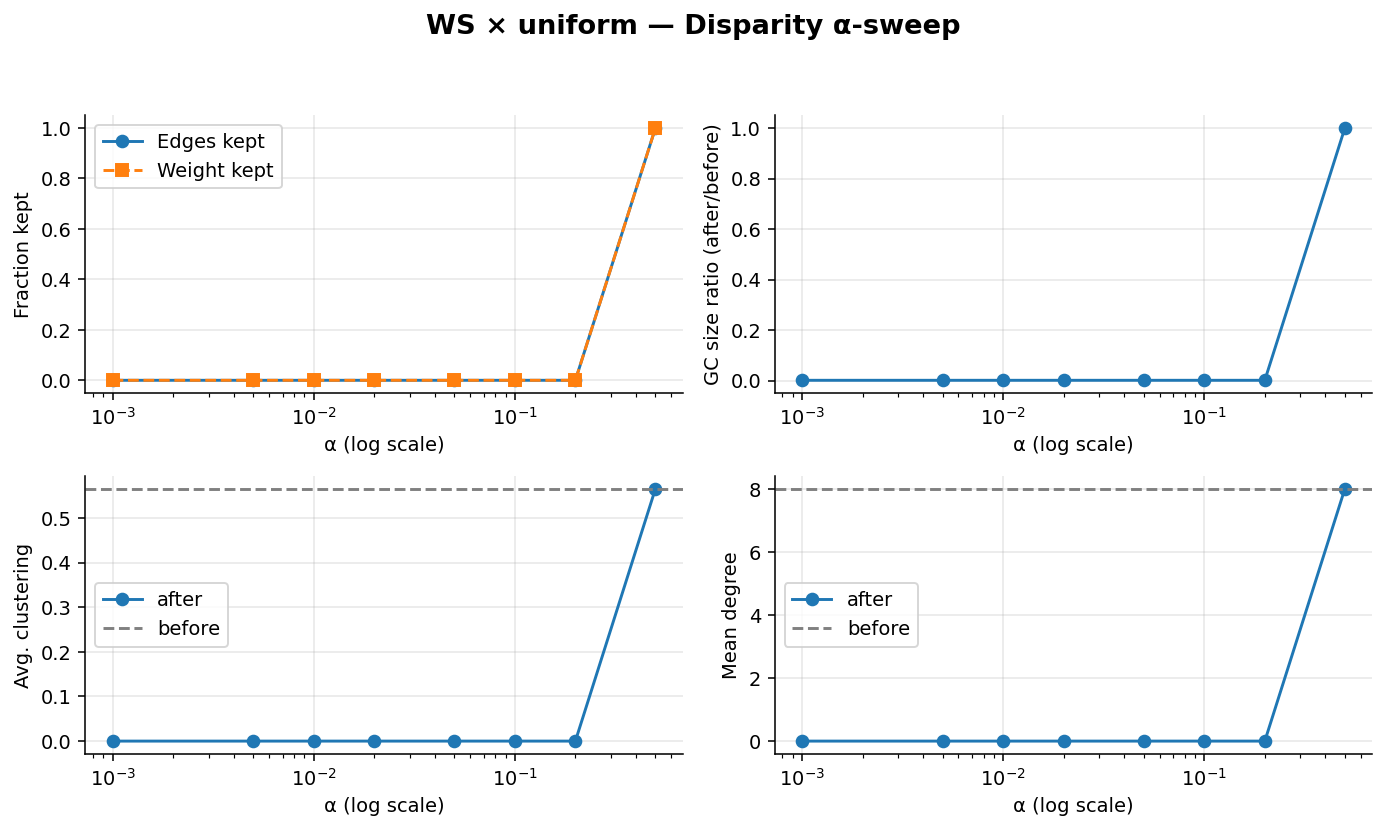


**WS × uniform — α-sweep numeric summary:**


,alpha,edges_kept_frac,weight_kept_frac,gc_after,clustering_after,mean_degree_after
0,0.001,0.0,0.0,1,0.0000,0.0
1,0.005,0.0,0.0,1,0.0000,0.0
2,0.010,0.0,0.0,1,0.0000,0.0
3,0.020,0.0,0.0,1,0.0000,0.0
4,0.050,0.0,0.0,1,0.0000,0.0
5,0.100,0.0,0.0,1,0.0000,0.0
6,0.200,0.0,0.0,1,0.0000,0.0
7,0.500,1.0,1.0,600,0.5653,8.0


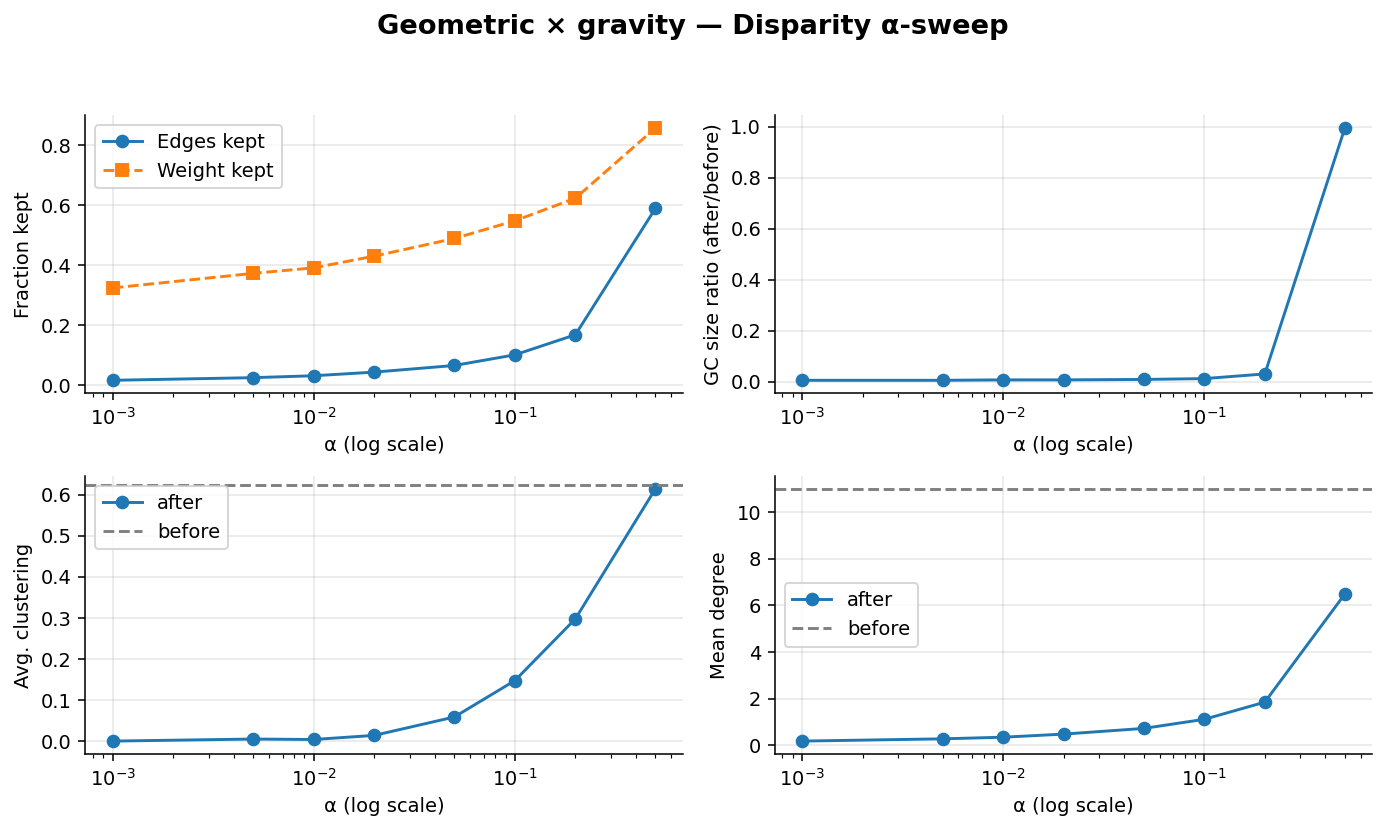


**Geometric × gravity — α-sweep numeric summary:**


,alpha,edges_kept_frac,weight_kept_frac,gc_after,clustering_after,mean_degree_after
0,0.001,0.0167,0.3247,3,0.0000,0.1833
1,0.005,0.0255,0.3733,3,0.0050,0.2800
2,0.010,0.0318,0.3917,4,0.0039,0.3500
3,0.020,0.0440,0.4308,4,0.0139,0.4833
4,0.050,0.0661,0.4896,5,0.0586,0.7267
5,0.100,0.1015,0.5486,7,0.1472,1.1167
6,0.200,0.1685,0.6238,18,0.2976,1.8533
7,0.500,0.5899,0.8580,597,0.6141,6.4867


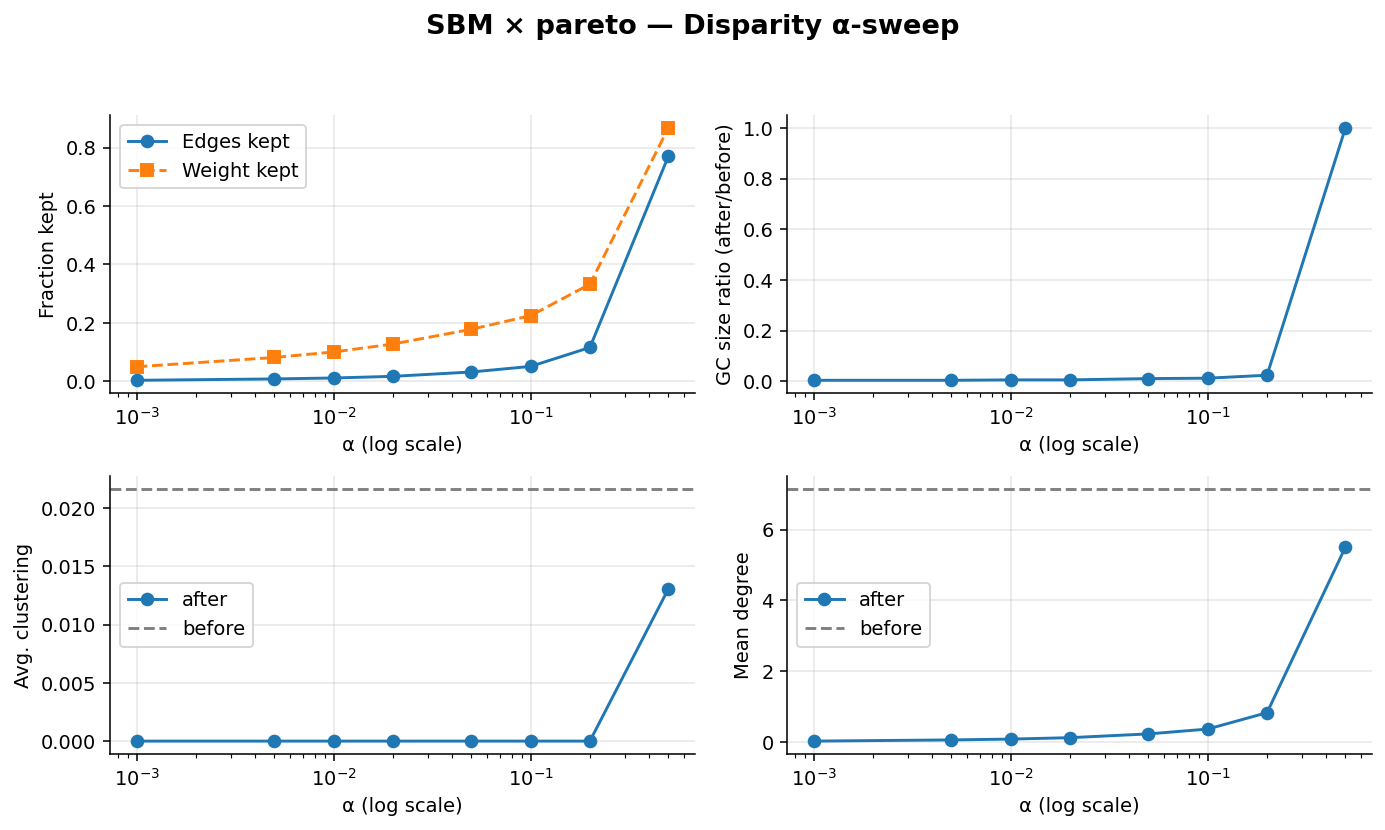


**SBM × pareto — α-sweep numeric summary:**


,alpha,edges_kept_frac,weight_kept_frac,gc_after,clustering_after,mean_degree_after
0,0.001,0.0033,0.0496,2,0.000,0.0233
1,0.005,0.0079,0.0814,2,0.000,0.0567
2,0.010,0.0112,0.1002,3,0.000,0.0800
3,0.020,0.0168,0.1273,3,0.000,0.1200
4,0.050,0.0317,0.1779,6,0.000,0.2267
5,0.100,0.0508,0.2245,7,0.000,0.3633
6,0.200,0.1156,0.3322,14,0.000,0.8267
7,0.500,0.7693,0.8667,599,0.013,5.5033


In [ ]:
# ---------------------------
# Driver
# ---------------------------
if __name__ == "__main__":
    suite = make_default_suite(n=600, seed=42)

    # Sweep parameters
    alphas = (0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.001)
    rule = "or"
    weight = "weight"
    seed = 123
    do_report = True
    do_sweep = True

    # Run
    results = run_disparity_alpha_sweep_suite(
        selections,
        suite,
        alphas=alphas,
        rule=rule,
        weight=weight,
        seed=seed,
        do_report=do_report,
        do_sweep=do_sweep,
        return_as="dataframe",
    )

    # Plot
    plot_alpha_sweep(results)


The **disparity filter** isolates the *statistically significant* edges of a weighted network by comparing each link’s share of a node’s strength to a null model where all weights around that node are **uniformly random**.

* **Low α → strict**: only the most dominant edges remain.
* **High α → lenient**: most edges survive.

As α decreases, expect **fewer edges**, **less retained weight**, and **shrinking connectivity** (smaller giant component, lower mean degree, lower clustering).

##### 1️⃣ BA × degprod

*(Scale-free topology + weights ∝ kᵢkⱼ)*

* For α < 0.1, almost no edge passes: the filter is extremely selective.
* Around α ≈ 0.2, a minimal backbone emerges (≈ 16 % of edges, only 2.7 % of weight).
* At α = 0.5, the network almost fully reconnects (≈ 85 % edges, 45 % weight).

**Interpretation:**
In BA graphs, hub–hub links are heavy due to structure itself, so they’re *not rare under the null*. Only when α relaxes do these edges regain significance.

**Takeaway:**
Backbone appears only at moderate α; significance is highly *localized* on hubs, emphasizing asymmetry between strong and weak nodes.

---

##### 2️⃣ ER × lognormal

*(Random topology + heavy-tailed independent weights)*

* For α ≤ 0.05: nearly all edges rejected → no local dominance detected.
* Around α ≈ 0.2: backbone percolates.
* By α = 0.5: ≈ 63 % of edges survive, yet weight retention (28 %) stays low.

**Interpretation:**
With no degree–weight correlation, disparity filtering acts like a *random sparsifier*.
The null assumption (uniform weights) actually fits the data, so only high α preserves connectivity.

**Takeaway:**
ER networks require higher α to remain connected; filtering doesn’t reveal meaningful hierarchy.

---

##### 3️⃣ WS × uniform

*(Small-world + flat weights)*

* All α → 0 edges survive; the filter wipes everything out.

**Interpretation:**
Uniform weights make every edge equally “important.”
The test statistic αᵢⱼ becomes constant, never below threshold — no link stands out.

**Takeaway:**
The filter *needs heterogeneity* to detect structure.
Uniform weights ⇒ no significance ⇒ empty backbone.

---

###### 4️⃣ Geometric × gravity

*(Spatial network + weights coupled to distance and degree)*

* Low α (< 0.05): backbone fragmented.
* α ≈ 0.2–0.5: sharp expansion; strong local clusters reappear.
* Clustering rises with α, showing persistent spatial cohesion.

**Interpretation:**
Because strong weights concentrate on short distances and high-degree nodes, these edges remain significant even under moderate α.

**Takeaway:**
Disparity filtering **reconstructs spatial cores** efficiently — retaining compact, cluster-like subgraphs while pruning weak long-range links.

---

##### 5️⃣ SBM × pareto

*(Community structure + bursty weights)*

* α ≤ 0.05: only extreme weights remain → network fragments.
* α ≥ 0.2: rapid backbone recovery; by 0.5, over half the edges and a full giant component restored.
* Clustering stays low → few dense triangles.

**Interpretation:**
Pareto burstiness creates a few dominant bridges between communities.
At low α, these dominate; as α rises, the intra-community scaffold resurfaces.

**Takeaway:**
Filtering first exposes *cross-community connectors*, then recovers the broader community mesh at moderate α.


##### Key Insights

* **Heterogeneity drives significance.**
  Networks with correlated or heavy-tailed weights yield meaningful backbones; homogeneous ones collapse.

* **α controls resolution.**

  * Small α → only statistically strongest links.
  * Large α → nearly original graph.

* **Best behaved cases:** BA and Geometric — gradual percolation, interpretable multi-scale backbone.

* **Null confirmation:** WS + uniform — no weight variability → no structure detected.

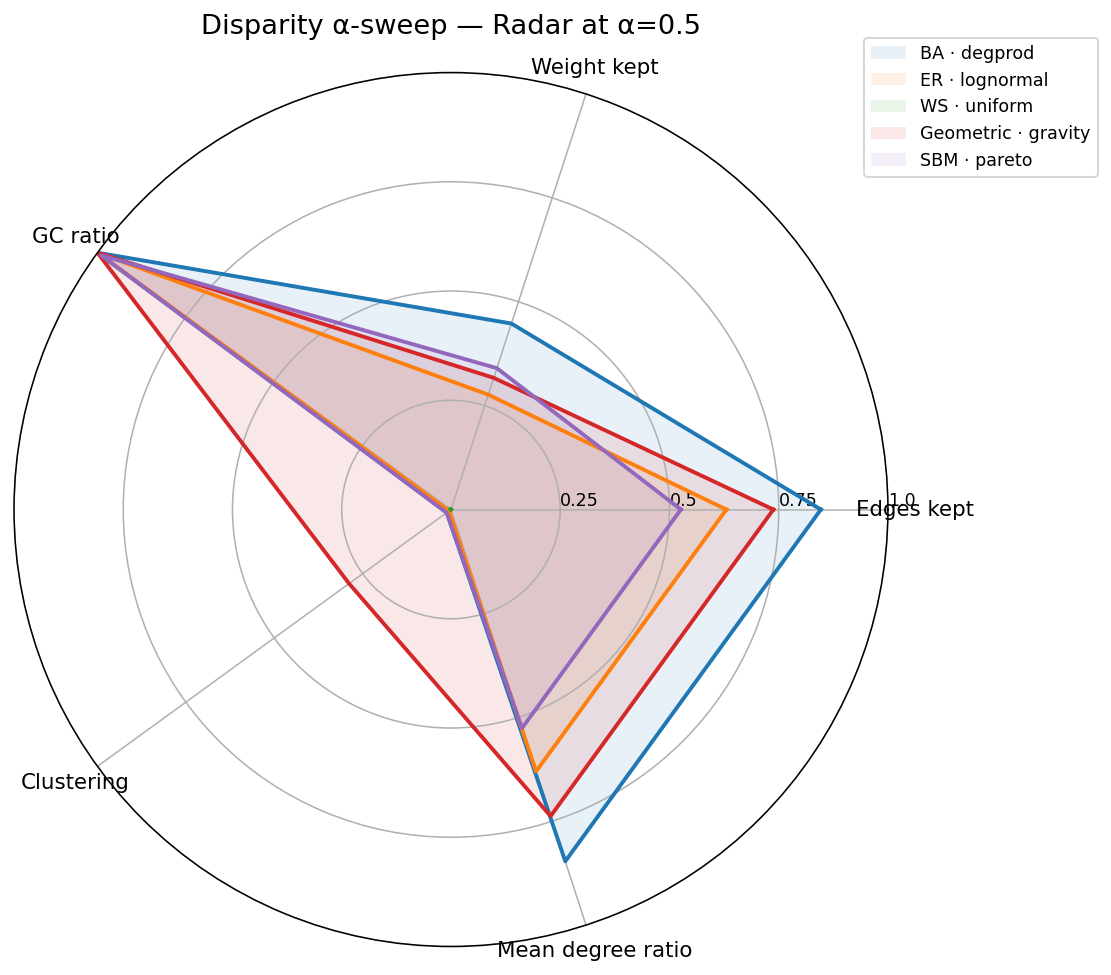

In [60]:
import math
import numpy as np
import matplotlib.pyplot as plt

def _nearest_alpha_row(df, alpha_target):
    # Try exact match; else pick nearest by absolute difference
    if (df["alpha"] == alpha_target).any():
        return df.loc[df["alpha"] == alpha_target].iloc[0]
    idx = (df["alpha"] - alpha_target).abs().argmin()
    return df.iloc[idx]

def plot_radar_at_alpha(results, alpha_target=0.5):
    """
    Radar plot across networks (each polygon is one (name, scheme))
    at the given alpha. Metrics are normalized to [0,1]:
      - edges_kept_frac
      - weight_kept_frac
      - gc_ratio = gc_after / gc_before
      - clustering_after
      - mean_degree_ratio = mean_degree_after / mean_degree_before
    """
    # Collect rows
    labels = []
    rows = []
    for (name, scheme), df in results.items():
        # Ensure DataFrame
        if not hasattr(df, "plot"):
            import pandas as pd
            df = pd.DataFrame(df)
        if df.empty:
            continue

        r = _nearest_alpha_row(df, alpha_target)
        # Safe ratios
        gc_before = float(r.get("gc_before", np.nan))
        gc_after  = float(r.get("gc_after",  np.nan))
        md_before = float(r.get("mean_degree_before", np.nan))
        md_after  = float(r.get("mean_degree_after",  np.nan))

        gc_ratio = np.nan if (gc_before == 0 or math.isnan(gc_before)) else gc_after / gc_before
        md_ratio = np.nan if (md_before == 0 or math.isnan(md_before)) else md_after / md_before

        row = {
            "edges_kept_frac": float(r.get("edges_kept_frac", np.nan)),
            "weight_kept_frac": float(r.get("weight_kept_frac", np.nan)),
            "gc_ratio": gc_ratio,
            "clustering_after": float(r.get("clustering_after", np.nan)),
            "mean_degree_ratio": md_ratio,
        }

        # Clamp to [0,1] and replace NaN with 0
        for k, v in row.items():
            if np.isnan(v):
                row[k] = 0.0
            else:
                row[k] = max(0.0, min(1.0, float(v)))

        labels.append(f"{name} · {scheme}")
        rows.append(row)

    if not rows:
        print("[warn] No data available to plot radar.")
        return

    # Radar categories
    metrics = ["edges_kept_frac", "weight_kept_frac", "gc_ratio", "clustering_after", "mean_degree_ratio"]
    metric_names = [
        "Edges kept",
        "Weight kept",
        "GC ratio",
        "Clustering",
        "Mean degree ratio",
    ]

    # Angles for radar
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    # Build value arrays
    value_sets = []
    for row in rows:
        vals = [row[m] for m in metrics]
        vals += vals[:1]  # close loop
        value_sets.append(vals)

    # Plot
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names, fontsize=11)

    # Set radial grid
    ax.set_rlabel_position(0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=9)
    ax.set_ylim(0, 1.0)

    # Draw each polygon
    for label, vals in zip(labels, value_sets):
        ax.plot(angles, vals, linewidth=2)
        ax.fill(angles, vals, alpha=0.1, label=label)

    plt.title(f"Disparity α-sweep — Radar at α={alpha_target}", fontsize=14, pad=20)
    plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=9)
    plt.tight_layout()
    plt.show()

# --- call it ---
plot_radar_at_alpha(results, alpha_target=0.5)


This **radar plot** provides a compact, multi-metric summary of how each network behaves under the disparity filter at α = 0.5.

---

**Axes (All Normalized)**

* **Edges kept:** $E_\alpha / E_0$ — fraction of edges surviving.
* **Weight kept:** $W_\alpha / W_0$ — total edge weight retained.
* **GC ratio:** $GC_\alpha / GC_0$ — relative giant component size.
* **Clustering:** average clustering coefficient (already ∈ [0,1]).
* **Mean degree ratio:** $\bar{k}_\alpha / \bar{k}_0$ — relative connectivity per node.

Each polygon represents one (network × weight scheme). Larger area → less pruning; the shape reveals *which features survive* (edges, weight, clustering, etc.).

---

## Interpretation of the Plot

**BA · degprod (blue)** — *largest, elongated polygon*

* High on Edges kept & Mean degree ratio (≈ 0.9).
* Moderate in Weight kept, low in Clustering.
  ✅ *Scale-free topology resists pruning; hubs preserve connectivity but remain triangle-poor.*

**ER · lognormal (orange)** — *medium polygon*

* Roughly 0.6–0.7 across most axes; Clustering ≈ 0.
  ✅ *Random graph retains moderate structure; filtering prunes weak links but keeps a connected core.*

**WS · uniform (green)** — *collapsed at the origin*
❌ *Uniform weights → no statistical dominance; disparity filter removes all edges.*

**Geometric · gravity (red)** — *broad, balanced polygon*

* Strong on Edges kept, GC ratio, Mean degree ratio.
* Slightly higher Clustering.
  ✅ *Spatial graph keeps cohesive, local clusters; backbone emphasizes short-distance, strong links.*

**SBM · pareto (purple)** — *moderate polygon*

* Edges ≈ 0.5, Weight ≈ 0.35, Clustering ≈ 0.
  ✅ *Bursty community graph preserves key inter/intra links, though few triangles remain.*

---

**In short:**
The radar plot visualizes each network’s *multi-criteria resilience* under disparity filtering.

* **BA & Geometric** → strong, interpretable backbones.
* **ER & SBM** → moderately structured.
* **WS** → null case: no heterogeneity, no backbone.
